In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# P100 GPU COMPATIBILITY FIX — Must run BEFORE any other imports
# ═══════════════════════════════════════════════════════════════════════════════
# PyTorch 2.6+ dropped SM 6.0 (P100) support. This cell detects the GPU
# and installs a compatible PyTorch version BEFORE torch is imported.
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess, sys, os

def ensure_p100_compatible_pytorch():
    """Install P100-compatible PyTorch if needed (before any torch imports)."""
    try:
        # Detect GPU compute capability using nvidia-smi (no torch needed)
        result = subprocess.run(
            ['nvidia-smi', '--query-gpu=name,compute_cap', '--format=csv,noheader'],
            capture_output=True, text=True, timeout=10
        )
        if result.returncode != 0:
            print("No GPU detected via nvidia-smi — skipping PyTorch fix")
            return

        gpu_info = result.stdout.strip().split('\n')[0]
        print(f"GPU detected: {gpu_info}")

        # Parse compute capability
        parts = gpu_info.split(',')
        if len(parts) >= 2:
            compute_cap = parts[-1].strip()
            major = int(compute_cap.split('.')[0])
        else:
            return

        if major >= 7:
            print(f"✓ Compute capability {compute_cap} — default PyTorch is compatible")
            return

        # Pascal (SM 6.x) or older — check if current PyTorch works
        print(f"⚠️ Pascal GPU detected (SM {compute_cap}) — checking PyTorch compatibility...")

        # Test if current torch works on this GPU (in a subprocess to avoid polluting our process)
        test = subprocess.run(
            [sys.executable, '-c',
             'import torch; torch.zeros(1, device="cuda"); print("OK")'],
            capture_output=True, text=True, timeout=30
        )
        if test.stdout.strip() == "OK":
            print("✓ Current PyTorch works on P100 — no fix needed")
            return

        # Current PyTorch is incompatible — install a compatible version
        # Get current version for logging
        ver_result = subprocess.run(
            [sys.executable, '-c', 'import torch; print(torch.__version__)'],
            capture_output=True, text=True, timeout=10
        )
        current_ver = ver_result.stdout.strip() if ver_result.returncode == 0 else 'unknown'
        print(f"❌ PyTorch {current_ver} does NOT support P100 (SM 6.0)")
        print(f"📦 Installing PyTorch 2.4.1+cu121 (last version with SM 6.0 support)...")
        print(f"   This takes 2-3 minutes. Please wait...")

        subprocess.check_call([
            sys.executable, '-m', 'pip', 'install', '-q',
            'torch==2.4.1+cu121',
            'torchvision==0.19.1+cu121',
            'torchaudio==2.4.1+cu121',
            '--index-url', 'https://download.pytorch.org/whl/cu121'
        ], timeout=600)

        print("✅ PyTorch 2.4.1+cu121 installed — P100 (SM 6.0) supported")

        # Verify the installation works
        verify = subprocess.run(
            [sys.executable, '-c',
             'import torch; torch.zeros(1, device="cuda"); print(torch.__version__)'],
            capture_output=True, text=True, timeout=30
        )
        if verify.returncode == 0:
            print(f"✅ Verified: PyTorch {verify.stdout.strip()} works on P100")
        else:
            print(f"⚠️ Verification failed: {verify.stderr}")

    except subprocess.TimeoutExpired:
        print("⚠️ PyTorch installation timed out")
        print("   Make sure internet is ENABLED in Kaggle notebook settings")
    except subprocess.CalledProcessError as e:
        print(f"⚠️ PyTorch installation failed (exit code {e.returncode})")
        print("   Make sure internet is ENABLED in Kaggle notebook settings")
        print("   If internet is disabled, you cannot use P100 with modern Kaggle")
        print("   Alternative: Switch to T4 GPU in Kaggle Settings")
    except Exception as e:
        print(f"⚠️ Could not check/fix PyTorch: {e}")

ensure_p100_compatible_pytorch()


GPU detected: Tesla P100-PCIE-16GB, 6.0
⚠️ Pascal GPU detected (SM 6.0) — checking PyTorch compatibility...
❌ PyTorch 2.10.0+cu128 does NOT support P100 (SM 6.0)
📦 Installing PyTorch 2.4.1+cu121 (last version with SM 6.0 support)...
   This takes 2-3 minutes. Please wait...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 16.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 102.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 76.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 45.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 95.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 15.8 MB/s eta 0:00:00

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# DEPENDENCY FIX FOR KAGGLE (V4 - INTERNET-SAFE)
# ═══════════════════════════════════════════════════════════════════════════════
# When Kaggle runs with internet OFF ('Save and Run All'), pip fails.
# Solution: Try to install, but DON'T crash — use pre-installed packages.
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess, sys

def safe_install():
    """Install deps gracefully — skip if no internet."""
    try:
        subprocess.run([
            sys.executable, '-m', 'pip', 'install', '-q',
            '--no-deps', 'facenet-pytorch==2.6.0'
        ], check=True, timeout=30)
        print('✓ facenet-pytorch installed')
    except Exception:
        print('⚠️ facenet-pytorch pip failed (no internet?) — checking pre-installed...')
        try:
            from facenet_pytorch import MTCNN
            print('  ✓ facenet-pytorch already available')
        except ImportError:
            print('  ⚠️ facenet-pytorch NOT available — will use OpenCV fallback')

    try:
        subprocess.run([
            sys.executable, '-m', 'pip', 'install', '-q', '--no-deps',  # Prevent torch upgrade
            'timm>=0.9.16',
            'albumentations>=1.4.20',
            'opencv-python-headless>=4.10.0.84',
            'seaborn>=0.12.0',
        ], check=True, timeout=60)
        print('✓ timm, albumentations, opencv, seaborn installed')
    except Exception:
        print('⚠️ pip install failed (no internet?) — using Kaggle pre-installed')
        import importlib
        for pkg in ['timm', 'albumentations', 'cv2', 'seaborn']:
            try:
                importlib.import_module(pkg)
                print(f'  ✓ {pkg} available')
            except ImportError:
                print(f'  ❌ {pkg} NOT available — this will cause errors!')

safe_install()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 37.4 MB/s eta 0:00:00
✓ facenet-pytorch installed
✓ timm, albumentations, opencv, seaborn installed


# CNN Spatio-Temporal Stream — Deepfake Detection

## Two-Stream Late Fusion Architecture (Stream 2 of 2)

This notebook implements a **research-grade Spatio-Temporal CNN** using Xception backbone with **BiLSTM Temporal Aggregation** for deepfake detection.

### Key Research Contributions:

1. **Temporal Modeling (BiLSTM + Multi-Head Attention)**
   - Unlike naive frame averaging, we model inter-frame dependencies
   - Detects temporal flickering, blending shifts, and motion anomalies
   - Enables detection of GAN/Diffusion artifacts that manifest across frames

2. **Grad-CAM Visualization**
   - Provides visual proof of what the model learns
   - Shows attention on facial regions (jawline, eyes, blending boundaries)
   - Essential for research paper methodology section

```
┌──────────────────────────────────────────────────────────────────────────────┐
│                    SPATIO-TEMPORAL ARCHITECTURE                              │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│   Video (T frames) ──→ MTCNN Face Detection ──→ T × (224, 224, 3) crops     │
│                                                                              │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  SPATIAL FEATURE EXTRACTION                                          │   │
│   │  Xception (pretrained, 2048-dim features per frame)          │   │
│   │                                                                      │   │
│   │      Frame 1 ──→ [f₁]                                               │   │
│   │      Frame 2 ──→ [f₂]     ──→ Feature Sequence (T × 1792)           │   │
│   │      ...                                                             │   │
│   │      Frame T ──→ [fₜ]                                               │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                              ↓                                               │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  TEMPORAL AGGREGATION (BiLSTM + Multi-Head Attention)               │   │
│   │                                                                      │   │
│   │  [f₁, f₂, ..., fₜ] ──→ BiLSTM (2-layer, bidirectional)              │   │
│   │                                ↓                                     │   │
│   │                    Multi-Head Self-Attention (4 heads)               │   │
│   │                                ↓                                     │   │
│   │                    Weighted Temporal Pooling                         │   │
│   │                                ↓                                     │   │
│   │                    Video-Level Representation (512-dim)              │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                              ↓                                               │
│   ┌─────────────────────────────────────────────────────────────────────┐   │
│   │  CLASSIFIER                                                          │   │
│   │  Linear(512 → 256) → BatchNorm → GELU → Dropout                     │   │
│   │  Linear(256 → 128) → BatchNorm → GELU → Dropout                     │   │
│   │  Linear(128 → 1) → Sigmoid                                          │   │
│   │                        ↓                                             │   │
│   │                    P_CNN (0 = Real, 1 = Fake)                        │   │
│   └─────────────────────────────────────────────────────────────────────┘   │
│                                                                              │
└──────────────────────────────────────────────────────────────────────────────┘

                    ↓ LATE FUSION ↓

        P_final = w₁ × P_CNN + w₂ × P_rPPG (from Stream 1)
```

**Output:** `cnn_predictions.csv` with video-level P_CNN scores for Late Fusion

In [3]:
import os
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'

root = "/kaggle/input"

# Verify Kaggle input path exists
print(f"Kaggle input root: {root}")
print(f"Root exists: {os.path.exists(root)}")


Kaggle input root: /kaggle/input
Root exists: True


In [4]:
import os

root = "/kaggle/input"

for current_path, dirs, files in os.walk(root):
    level = current_path.replace(root, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(current_path)}/")

input/
    datasets/
        xdxd003/
            ff-c23/
                FaceForensics++_C23/
                    Face2Face/
                    csv/
                    Deepfakes/
                    DeepFakeDetection/
                    original/
                    NeuralTextures/
                    FaceShifter/
                    FaceSwap/
        reubensuju/
            celeb-df-v2/
                YouTube-real/
                Celeb-synthesis/
                Celeb-real/
        lalith023/
            400videos/
                content/
                    drive/
                        MyDrive/
                            face_dataset_dip/
                                real_videos/
                                deepfake_videos/
            dfdc-sample-videos/


## 1. Setup & Imports

In [5]:
# Placeholder cell - can be used for additional configuration


In [6]:
# timm install handled in Cell 5


In [7]:
# All dependencies are now handled safely in Cell 1 to prevent numpy ABI crashes.


DATA LOADING

In [8]:
import re
# ═══════════════════════════════════════════════════════════════════════
# UNIFIED DATA COMPILER — Run ONCE before all other cells
# Creates master_dataset_index.csv used by both CNN + rPPG notebooks
# Guarantees: alignment, balance, P100-safe RAM, no metadata bottleneck
# ═══════════════════════════════════════════════════════════════════════

import os, json, random
import pandas as pd
import numpy as np
random.seed(42)
np.random.seed(42)

OUTPUT_CSV    = "/kaggle/working/master_dataset_index.csv"
VIDEO_EXTS    = ('.mp4', '.avi', '.mov', '.mkv', '.webm')
MAX_PER_CLASS = 200  # per source — keeps total ~1600 videos, safe for P100


def _extract_video_identity(filepath, source):
    """
    Extract the PERSON identity from the video filename.
    This is CRITICAL for identity-aware splitting (data leakage prevention).
    
    FaceForensics++ naming: <source_id>_<target_id>.mp4 (e.g., 001_870.mp4)
      → Identity = source person "001" (same person across manipulations)
    Celeb-DF naming: id<N>_id<M>_<clip>.mp4
      → Identity = "id<N>" (the real person's identity)
    DFDC naming: <hash>.mp4 with metadata.json providing 'original' field
      → Identity from filename prefix
    Custom: group by filename stem before last underscore
    """
    basename = os.path.splitext(os.path.basename(filepath))[0]
    
    # FaceForensics++ patterns: "001_870" or "001" 
    # Identity = first numeric ID (the source person)
    if source.startswith("FF_"):
        match = re.match(r"^(\d+)", basename)
        if match:
            return f"FF_person_{match.group(1)}"
        return f"FF_{basename}"
    
    # Celeb-DF: "id0_id1_0003" → person "id0"
    if source.startswith("Celeb_") or source.startswith("YT_"):
        match = re.match(r"^(id\d+)", basename)
        if match:
            return f"Celeb_person_{match.group(1)}"
        return f"Celeb_{basename}"
    
    # DFDC: use the filename as identity (each video is independent)
    if source == "DFDC":
        return f"DFDC_{basename}"
    
    # Custom dataset: group by numeric prefix or first segment  
    match = re.match(r"^([a-zA-Z]*\d+)", basename)
    if match:
        return f"Custom_person_{match.group(1)}"
    return f"Custom_{basename}"

def scan_folder(folder, label, source, max_n=MAX_PER_CLASS):
    if not os.path.exists(folder):
        print(f"  ⚠️  NOT FOUND: {folder}")
        return []
    # FIXED: os.walk() is recursive — finds videos in subdirectories
    files = []
    for root, dirs, fnames in os.walk(folder):
        for f in fnames:
            if f.lower().endswith(VIDEO_EXTS):
                files.append(os.path.join(root, f))
    files = sorted(files)
    if len(files) > max_n:
        files = random.sample(files, max_n)
    # FIXED: use relative path in video_id to prevent basename collisions
    records = [{'video_id': f"{source}__{os.path.relpath(f, folder).replace(os.sep, '_')}",
                'path':     f,
                'label':    label,
                'source':   source,
                'identity': _extract_video_identity(f, source)} for i, f in enumerate(files)]  # FIXED: groups by PERSON identity
    print(f"  ✓ {source:30s} | label={label} | {len(records):4d} videos")
    return records

# ── MUST initialize all_records BEFORE any scan calls ────────────────
all_records = []

# ── 1. FaceForensics++ ───────────────────────────────────────────────
print("\n── FaceForensics++ ─────────────────────────────────────────────")
FF_BASE = "/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23"
all_records += scan_folder(f"{FF_BASE}/original",          0, "FF_real")
all_records += scan_folder(f"{FF_BASE}/Deepfakes",         1, "FF_Deepfakes")
all_records += scan_folder(f"{FF_BASE}/Face2Face",         1, "FF_Face2Face")
all_records += scan_folder(f"{FF_BASE}/FaceSwap",          1, "FF_FaceSwap")
all_records += scan_folder(f"{FF_BASE}/NeuralTextures",    1, "FF_NeuralTextures")
all_records += scan_folder(f"{FF_BASE}/FaceShifter",       1, "FF_FaceShifter")
# FIXED: DeepFakeDetection now placed AFTER initialization, in correct position
all_records += scan_folder(f"{FF_BASE}/DeepFakeDetection", 1, "FF_DeepFakeDetection")

# ── 2. Celeb-DF v2 ───────────────────────────────────────────────────
print("\n── Celeb-DF v2 ─────────────────────────────────────────────────")
CELEB_BASE = "/kaggle/input/datasets/reubensuju/celeb-df-v2"
all_records += scan_folder(f"{CELEB_BASE}/Celeb-real",      0, "Celeb_real",  max_n=150)
all_records += scan_folder(f"{CELEB_BASE}/YouTube-real",    0, "YT_real",     max_n=50)
all_records += scan_folder(f"{CELEB_BASE}/Celeb-synthesis", 1, "Celeb_fake",  max_n=200)

# ── 3. Custom Dataset (lalith023) ────────────────────────────────────
print("\n── Custom Dataset (400 Videos) ─────────────────────────────────")
CUSTOM_BASE = "/kaggle/input/datasets/lalith023/400videos/content/drive/MyDrive/face_dataset_dip"
all_records += scan_folder(f"{CUSTOM_BASE}/real_videos",     0, "Custom_real", max_n=400)
all_records += scan_folder(f"{CUSTOM_BASE}/deepfake_videos", 1, "Custom_fake", max_n=400)

# ── 4. DFDC ──────────────────────────────────────────────────────────
print("\n── DFDC ────────────────────────────────────────────────────────")
DFDC_DIR = "/kaggle/input/datasets/lalith023/dfdc-sample-videos"
dfdc_real, dfdc_fake = [], []
if os.path.exists(DFDC_DIR):
    meta_path = os.path.join(DFDC_DIR, "metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path, 'r') as f:
            meta = json.load(f)
        for filename, info in meta.items():
            path = os.path.join(DFDC_DIR, filename)
            if not os.path.exists(path):
                continue
            rec = {'video_id': f"DFDC__{filename}",
                   'path':     path,
                   'label':    1 if info['label'] == 'FAKE' else 0,
                   'source':   'DFDC',
                   'identity': f"DFDC_{os.path.splitext(filename)[0]}"}
            if info['label'] == 'REAL':
                dfdc_real.append(rec)
            else:
                dfdc_fake.append(rec)
        n = len(dfdc_real)
        all_records += dfdc_real
        if len(dfdc_fake) > 0 and n > 0:
            all_records += random.sample(dfdc_fake, min(n, len(dfdc_fake)))
        if n == 0:
            print(f"  ⚠️  DFDC has 0 real videos — skipping DFDC fake videos")
        print(f"  ✓ {'DFDC':30s} | real={len(dfdc_real)} | fake={min(n, len(dfdc_fake))}")
    else:
        print(f"  ⚠️  metadata.json not found in {DFDC_DIR}")
else:
    print(f"  ⚠️  DFDC dir not found: {DFDC_DIR}")

# Guard: fail loudly if data is critically missing
assert len(all_records) >= 500, \
    f"FATAL: Only {len(all_records)} total videos found — need at least 500. Check all dataset paths above!"
n_real_pre = sum(1 for r in all_records if r['label'] == 0)
n_fake_pre = sum(1 for r in all_records if r['label'] == 1)
assert n_real_pre >= 50, f"FATAL: Only {n_real_pre} real videos — check real dataset paths!"
assert n_fake_pre >= 50, f"FATAL: Only {n_fake_pre} fake videos — check fake dataset paths!"

# ── Calculate class weights instead of discarding samples ────────────
df     = pd.DataFrame(all_records)
n_real = len(df[df['label'] == 0])
n_fake = len(df[df['label'] == 1])
print(f"\n── Dataset Balance ─────────────────────────────────────────────")
print(f"  Real : {n_real}")
print(f"  Fake : {n_fake}")

# Calculate class imbalance ratio for reference
# Note: FocalLoss with alpha=0.5 inherently handles class weighting
# by applying balanced weights to both classes
n_ratio = n_real / n_fake if n_fake > 0 else 1.0
print(f"  Real/Fake ratio: {n_ratio:.2f}")
print(f"  ✓ FocalLoss alpha is handled via Config")
print(f"  ✓ All samples retained (no discarding)")

# Shuffle the dataframe
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# ── Verify every path actually exists ────────────────────────────────
missing = df[~df['path'].apply(os.path.exists)]
if len(missing) > 0:
    print(f"\n  ⚠️  Removing {len(missing)} missing paths")
    df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)

# ── Save ─────────────────────────────────────────────────────────────

# ── BALANCE CLASSES ──────────────────────────────────────────────
n_real_final = len(df[df["label"] == 0])
n_fake_final = len(df[df["label"] == 1])
min_n = min(n_real_final, n_fake_final)
if n_real_final != n_fake_final:
    df_real = df[df["label"] == 0].sample(n=min_n, random_state=42)
    df_fake = df[df["label"] == 1].sample(n=min_n, random_state=42)
    df = pd.concat([df_real, df_fake]).sample(frac=1, random_state=42).reset_index(drop=True)
    print(f"  ✓ Balanced: {min_n} real + {min_n} fake = {len(df)} total")

df.to_csv(OUTPUT_CSV, index=False)

print(f"\n{'='*60}")
print(f"✅ master_dataset_index.csv saved → {OUTPUT_CSV}")
print(f"{'='*60}")
print(f"  Total  : {len(df)}")
print(f"  Real   : {len(df[df['label']==0])}")
print(f"  Fake   : {len(df[df['label']==1])}")
print(f"  Missing: {len(missing)}")
print(f"\n  Source breakdown:")
print(df.groupby(['source','label']).size().to_string())
print(f"\n  ✓ Both CNN and rPPG notebooks read from this file.")
print(f"  ✓ video_id is globally unique — fusion alignment guaranteed.")



── FaceForensics++ ─────────────────────────────────────────────
  ✓ FF_real                        | label=0 |  200 videos
  ✓ FF_Deepfakes                   | label=1 |  200 videos
  ✓ FF_Face2Face                   | label=1 |  200 videos
  ✓ FF_FaceSwap                    | label=1 |  200 videos
  ✓ FF_NeuralTextures              | label=1 |  200 videos
  ✓ FF_FaceShifter                 | label=1 |  200 videos
  ✓ FF_DeepFakeDetection           | label=1 |  200 videos

── Celeb-DF v2 ─────────────────────────────────────────────────
  ✓ Celeb_real                     | label=0 |  150 videos
  ✓ YT_real                        | label=0 |   50 videos
  ✓ Celeb_fake                     | label=1 |  200 videos

── Custom Dataset (400 Videos) ─────────────────────────────────
  ✓ Custom_real                    | label=0 |  400 videos
  ✓ Custom_fake                    | label=1 |  400 videos

── DFDC ────────────────────────────────────────────────────────
  ✓ DFDC                    

In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
# IMPORTS (P100 COMPATIBLE - STRICT FP32, NO AMP)
# ═══════════════════════════════════════════════════════════════════════════════

import os
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'

import re
import gc
import cv2
cv2.setNumThreads(0)
import json
import math
import random
import warnings
import numpy as np
import pandas as pd
from collections import defaultdict
from typing import List, Tuple, Dict, Optional
from tqdm.auto import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.swa_utils import AveragedModel, update_bn, SWALR

import timm
from facenet_pytorch import MTCNN
import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GroupKFold, StratifiedGroupKFold)
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score,
                             classification_report, roc_curve,
                             precision_score, recall_score,
                             average_precision_score)

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# Issue 16: Remove deterministic mode to avoid 9-hour timeout
# torch.backends.cudnn.deterministic = True  # REMOVED - causes ~40% slowdown
torch.backends.cudnn.benchmark = False  # P100 FIX: Must be False for LSTM stability

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    cap = torch.cuda.get_device_capability(0)
    print(f"Compute Capability: {cap[0]}.{cap[1]}")
    if cap[0] < 7:
        print("⚠️ PASCAL GPU — Strict FP32")


Device: cuda
GPU: Tesla P100-PCIE-16GB
Memory: 17.1 GB
Compute Capability: 6.0
⚠️ PASCAL GPU — Strict FP32


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE PREFLIGHT CHECK — Validates EVERYTHING Before Training
# ═══════════════════════════════════════════════════════════════════════════════
# Tests ALL imports, CUDA operations, model loading, and data availability
# BEFORE the expensive face extraction starts (~2 hours).
# If anything will fail, it fails HERE in 30 seconds.
# ═══════════════════════════════════════════════════════════════════════════════

import sys, importlib, traceback

def run_preflight_check():
    """Run comprehensive preflight validation."""
    print('=' * 70)
    print('PREFLIGHT CHECK — Validating all dependencies before training')
    print('=' * 70)

    passed = 0
    failed = 0
    total = 0
    results = []
    warnings_list = []
    fatal_errors = []

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 1: PYTHON PACKAGE IMPORTS
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 1: Python Package Imports ──────────────────────────")

    # ── 1a. Core packages ──
    core_packages = [
        ('torch', 'PyTorch'),
        ('torchvision', 'TorchVision'),
        ('numpy', 'NumPy'),
        ('pandas', 'Pandas'),
        ('cv2', 'OpenCV'),
        ('PIL', 'Pillow'),
        ('tqdm', 'tqdm'),
        ('matplotlib', 'Matplotlib'),
    ]
    for pkg, name in core_packages:
        total += 1
        try:
            mod = importlib.import_module(pkg)
            ver = getattr(mod, '__version__', 'ok')
            results.append((f"{name}", f"✅ {ver}"))
            passed += 1
        except Exception as e:
            results.append((f"{name}", f"❌ {e}"))
            fatal_errors.append(f'{name} ({pkg}): {e}')
            failed += 1

    # ── 1b. ML packages ──
    ml_packages = [
        ('sklearn', 'scikit-learn'),
        ('scipy', 'SciPy'),
    ]
    for pkg, name in ml_packages:
        total += 1
        try:
            importlib.import_module(pkg)
            results.append((f"{name}", "✅"))
            passed += 1
        except Exception as e:
            results.append((f"{name}", f"❌ {e}"))
            fatal_errors.append(f'{name}: {e}')
            failed += 1

    # ── 1c. timm ──
    total += 1
    try:
        import timm
        results.append(("timm", f"✅ {timm.__version__}"))
        passed += 1
    except Exception as e:
        results.append(("timm", f"❌ {e}"))
        fatal_errors.append(f'timm: {e}')
        failed += 1

    # ── 1d. albumentations ──
    total += 1
    try:
        import albumentations as A
        results.append(("albumentations", f"✅ {A.__version__}"))
        passed += 1
    except Exception as e:
        results.append(("albumentations", f"❌ {e}"))
        fatal_errors.append(f'albumentations: {e}')
        failed += 1

    # ── 1e. facenet-pytorch (MTCNN) ──
    total += 1
    try:
        from facenet_pytorch import MTCNN
        results.append(("facenet-pytorch (MTCNN)", "✅"))
        passed += 1
    except Exception as e:
        results.append(("facenet-pytorch (MTCNN)", f"⚠️ {e} — will use center-crop fallback"))
        warnings_list.append(f'MTCNN not available: {e}')
        passed += 1  # Not fatal — has fallback


    passed += 0  # No transformers needed for this notebook

    # ── 1g. torch sub-modules ──
    torch_submodules = [
        ('torch.nn', 'torch.nn'),
        ('torch.nn.functional', 'torch.nn.functional'),
        ('torch.optim', 'torch.optim'),
        ('torch.utils.data', 'torch.utils.data'),
    ]
    for pkg, name in torch_submodules:
        total += 1
        try:
            importlib.import_module(pkg)
            results.append((name, "✅"))
            passed += 1
        except Exception as e:
            results.append((name, f"❌ {e}"))
            fatal_errors.append(f'{name}: {e}')
            failed += 1

    # ── 1h. SWA utilities ──
    total += 1
    try:
        from torch.optim.swa_utils import AveragedModel, update_bn, SWALR
        results.append(("SWA utils", "✅"))
        passed += 1
    except Exception as e:
        results.append(("SWA utils", f"❌ {e}"))
        fatal_errors.append(f'SWA utils: {e}')
        failed += 1

    # ── 1i. sklearn sub-modules ──
    total += 1
    try:
        from sklearn.model_selection import StratifiedGroupKFold
        from sklearn.metrics import accuracy_score, roc_auc_score, f1_score
        results.append(("sklearn (metrics + splits)", "✅"))
        passed += 1
    except Exception as e:
        results.append(("sklearn (metrics + splits)", f"❌ {e}"))
        fatal_errors.append(f'sklearn: {e}')
        failed += 1

    for name, status in results:
        print(f"  {status:40s}  {name}")

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 2: CUDA / GPU VALIDATION
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 2: CUDA / GPU Validation ───────────────────────────")
    import torch

    total += 1
    if not torch.cuda.is_available():
        results_gpu = [("CUDA available", "⚠️ No GPU — training will be VERY slow")]
        warnings_list.append('No GPU detected')
        passed += 1
    else:
        gpu_name = torch.cuda.get_device_name(0)
        gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
        cap = torch.cuda.get_device_capability(0)
        print(f"  GPU: {gpu_name} | Memory: {gpu_mem:.1f} GB | SM {cap[0]}.{cap[1]}")
        print(f"  PyTorch: {torch.__version__} | CUDA: {torch.version.cuda}")
        passed += 1  # CUDA is available

        cuda_tests = [
            ('Tensor creation',  lambda: torch.zeros(2, device='cuda')),
            ('torch.arange',     lambda: torch.arange(4, device='cuda')),
            ('torch.roll',       lambda: torch.roll(torch.arange(4, device='cuda'), 1)),
            ('torch.randn',      lambda: torch.randn(4, 4, device='cuda')),
            ('Matrix multiply',  lambda: torch.mm(torch.randn(4,4,device='cuda'), torch.randn(4,4,device='cuda'))),
            ('Conv2d forward',   lambda: torch.nn.Conv2d(3,16,3,padding=1).cuda()(torch.randn(1,3,32,32,device='cuda'))),
            ('LSTM forward',     lambda: torch.nn.LSTM(64,32,batch_first=True).cuda()(torch.randn(1,4,64,device='cuda'))),
            ('BatchNorm',        lambda: torch.nn.BatchNorm1d(64).cuda()(torch.randn(2,64,device='cuda'))),
            ('Sigmoid',          lambda: torch.sigmoid(torch.randn(4, device='cuda'))),
            ('Softmax',          lambda: torch.nn.functional.softmax(torch.randn(4, device='cuda'), dim=0)),
            ('BCE Loss',         lambda: torch.nn.functional.binary_cross_entropy_with_logits(torch.randn(4,device='cuda'), torch.ones(4,device='cuda'))),
        ]

        all_cuda_pass = True
        for test_name, test_fn in cuda_tests:
            total += 1
            try:
                with torch.no_grad():
                    test_fn()
                print(f"  ✅ {test_name}")
                passed += 1
            except Exception as e:
                print(f"  ❌ {test_name}: {e}")
                fatal_errors.append(f'CUDA {test_name}: {e}')
                failed += 1
                all_cuda_pass = False

        if not all_cuda_pass:
            print(f"\n  ❌ CUDA tests failed! PyTorch {torch.__version__} is NOT compatible with {gpu_name}")
            print(f"     The P100 fix cell should have installed a compatible version.")
            print(f"     Try: Kernel → Restart → Run All")

        torch.cuda.empty_cache()

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 3: MODEL LOADING TEST
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 3: Model Loading ───────────────────────────────────")

    total += 1
    try:
        import timm
        _test_model = timm.create_model('xception', pretrained=False, num_classes=0)
        n_params = sum(p.numel() for p in _test_model.parameters())
        # Get feature dim
        _dummy = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            _feat = _test_model(_dummy)
        feat_dim = _feat.shape[-1]
        print(f"  ✅ xception: {n_params/1e6:.1f}M params, feature_dim={feat_dim}")
        del _test_model, _dummy, _feat
        passed += 1
    except Exception as e:
        print(f"  ❌ Failed to load xception: {e}")
        fatal_errors.append(f'Model loading ({model_name}): {e}')
        failed += 1

    # Test model on GPU
    if torch.cuda.is_available():
        total += 1
        try:
            _test_model = timm.create_model('xception', pretrained=False, num_classes=0).cuda()
            _dummy = torch.randn(1, 3, 224, 224, device='cuda')
            with torch.no_grad():
                _feat = _test_model(_dummy)
            print(f"  ✅ Model forward pass on GPU: output shape {_feat.shape}")
            del _test_model, _dummy, _feat
            torch.cuda.empty_cache()
            passed += 1
        except Exception as e:
            print(f"  ❌ Model GPU forward pass failed: {e}")
            fatal_errors.append(f'Model GPU forward: {e}')
            failed += 1

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 4: DATASET AVAILABILITY
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 4: Dataset Paths ───────────────────────────────────")
    import os
    dataset_paths = [
        '/kaggle/input',
        '/kaggle/working',
    ]
    for p in dataset_paths:
        total += 1
        if os.path.exists(p):
            print(f"  ✅ {p} exists")
            passed += 1
        else:
            print(f"  ⚠️ {p} not found (expected on Kaggle)")
            warnings_list.append(f'{p} not found')
            passed += 1  # Not fatal locally

    # ══════════════════════════════════════════════════════════════════════
    # SECTION 5: MEMORY CHECK
    # ══════════════════════════════════════════════════════════════════════
    print("\n── Section 5: Memory ──────────────────────────────────────────")
    if torch.cuda.is_available():
        total += 1
        free_mem = (torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)) / 1e9
        print(f"  GPU free: {free_mem:.1f} GB")
        if free_mem < 10:
            warnings_list.append(f"Low GPU memory: {free_mem:.1f} GB free")
        passed += 1

    import psutil
    total += 1
    try:
        ram = psutil.virtual_memory()
        print(f"  RAM: {ram.available/1e9:.1f} GB available / {ram.total/1e9:.1f} GB total")
        passed += 1
    except:
        print(f"  RAM: could not determine (psutil not available)")
        passed += 1

    # ══════════════════════════════════════════════════════════════════════
    # SUMMARY
    # ══════════════════════════════════════════════════════════════════════
    print()
    print('=' * 70)
    if failed == 0:
        print(f"✅ PREFLIGHT CHECK PASSED ({passed}/{total} checks passed)")
        if warnings_list:
            print(f"   ⚠️ {len(warnings_list)} warning(s):")
            for w in warnings_list:
                print(f"      • {w}")
        print(f"\n   Safe to proceed with face extraction and training.")
    else:
        print(f"❌ PREFLIGHT CHECK FAILED ({failed} error(s) out of {total} checks)")
        print(f"\n   Fatal errors:")
        for e in fatal_errors:
            print(f"      ❌ {e}")
        if warnings_list:
            print(f"\n   Warnings:")
            for w in warnings_list:
                print(f"      ⚠️ {w}")
        print(f"\n   ⛔ DO NOT proceed — fix the errors above first.")
        raise RuntimeError(f'Preflight check failed with {failed} error(s). Fix the issues above before training.')
    print('=' * 70)

run_preflight_check()


PREFLIGHT CHECK — Validating all dependencies before training

── Section 1: Python Package Imports ──────────────────────────
  ✅ 2.4.1+cu121                             PyTorch
  ✅ 0.19.1+cu121                            TorchVision
  ✅ 2.0.2                                   NumPy
  ✅ 2.3.3                                   Pandas
  ✅ 4.13.0                                  OpenCV
  ✅ 11.3.0                                  Pillow
  ✅ 4.67.3                                  tqdm
  ✅ 3.10.0                                  Matplotlib
  ✅                                         scikit-learn
  ✅                                         SciPy
  ✅ 1.0.25                                  timm
  ✅ 2.0.8                                   albumentations
  ✅                                         facenet-pytorch (MTCNN)
  ✅                                         torch.nn
  ✅                                         torch.nn.functional
  ✅                                         torch.optim
  

In [11]:
# ═══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION — P100 Optimized + ALL ENHANCEMENTS
# ═══════════════════════════════════════════════════════════════════════════════

import math, re

class Config:
    EXPERIMENT_NAME    = "CNN_Xception_BiLSTM_Attn_AllEnhancements"
    EXPERIMENT_VERSION = "v7.0_optimized_accuracy"

    # ── Dataset ──────────────────────────────────────────────────────
    MASTER_CSV  = "/kaggle/working/master_dataset_index.csv"
    OUTPUT_DIR  = "/kaggle/working"
    FACE_CACHE  = "/kaggle/working/face_cache"

    # ── Pre-extracted cache (skip 1h face extraction) ────────────
    PREEXTRACTED_CACHE = "/kaggle/input/datasets/lalith023/feature-extraction/face_cache"
    PREEXTRACTED_INDEX = "/kaggle/input/datasets/lalith023/feature-extraction/cache_index.json"
    PREEXTRACTED_CSV   = "/kaggle/input/datasets/lalith023/feature-extraction/master_dataset_index.csv"

    # ── Frame extraction ─────────────────────────────────────────────
    FRAMES_PER_VIDEO = 16     # Safe for P100: B*T=32 prevents OOM
    IMG_SIZE         = 299    # Xception requirement

    # ── P100 memory ──────────────────────────────────────────────────
    BATCH_SIZE              = 2   # Safe for P100 16GB (effective batch = 16)
    GRAD_ACCUMULATION_STEPS = 8   # Effective batch size = 16 (BATCH_SIZE × GRAD_ACCUM)
    NUM_WORKERS             = 0   # P100: Must be 0 to avoid worker crashes

    # ── Training ─────────────────────────────────────────────────────
    NUM_EPOCHS    = 40        # P100 FIX: 50 epochs risks exceeding 12h Kaggle limit
    LEARNING_RATE = 1e-4      # lower LR — more stable with Xception
    WEIGHT_DECAY  = 1e-2
    WARMUP_RATIO  = 0.1      # shorter warmup — real learning starts epoch 2

    # ── Loss ─────────────────────────────────────────────────────────
    FOCAL_ALPHA     = 0.50    # Balanced data (877 real, 877 fake) → alpha=0.5
    FOCAL_GAMMA     = 2.0
    LABEL_SMOOTHING = 0.05    # OPTIMIZED: 0.05 works better for binary classification

    # ── Model ────────────────────────────────────────────────────────
    MODEL_NAME      = "xception"
    DROPOUT         = 0.3   # FIXED: 0.3 appropriate for ~1600 video dataset
    HIDDEN_DIM      = 256
    TEMPORAL_TYPE   = "bilstm_attention"
    LSTM_HIDDEN     = 256
    LSTM_LAYERS     = 2
    ATTENTION_HEADS = 4
    FREEZE_BACKBONE = True   # FIXED: Backbone IS frozen initially (UNFREEZE_EPOCH=5 > 0)

    # ── Curriculum / Progressive training ───────────────────────────
    UNFREEZE_EPOCH        = 5    # unfreeze backbone at epoch 5
    HARD_MINING_EPOCH     = 10   # start hard negative mining at epoch 10
    MIXUP_ALPHA           = 0.2  # mixup blend strength
    USE_MIXUP             = True
    USE_PROGRESSIVE_FRAMES = False  # FIXED: was True — causes train/val temporal mismatch (train=5 frames, val=16 frames)

    # ── SWA ──────────────────────────────────────────────────────────
    USE_SWA       = True
    SWA_START     = 15            # FIX: Earlier start to ensure SWA gets 5+ epochs
    SWA_LR        = 5e-5         # SWA learning rate

    # ── Splits ───────────────────────────────────────────────────────
    # ISSUE 4 NOTE: This is a SINGLE-FOLD experiment (fold 0 only).
    # K_FOLDS=5 defines the split strategy but no fold loop exists.
    # For full 5-fold CV, run this notebook 5 times with CURRENT_FOLD=0,1,2,3,4
    # and report mean±std across folds in the paper.
    K_FOLDS            = 5
    CURRENT_FOLD       = 0   # Change to 1,2,3,4 for other folds
    USE_IDENTITY_SPLIT = True
    TRAIN_RATIO        = 0.8
    VAL_RATIO          = 0.2

    # ── Early Stopping ───────────────────────────────────────────────
    PATIENCE = 25  # FIX: More patience to ensure SWA gets decent snapshots

    # ── Checkpoint Resuming (Multi-Session Training) ────────────
    # Phase 1: RESUME_FROM="" and RESUME_EPOCH=0 (fresh start)
    # Phase 2: RESUME_FROM="/kaggle/input/YOUR-DATASET/best_cnn_model_fold0.pth"
    #          RESUME_EPOCH=15 (or wherever Phase 1 stopped)
    RESUME_FROM  = ""   # path to checkpoint (empty = fresh start)
    RESUME_EPOCH = 0    # epoch to resume from (0 = fresh start)

    @classmethod
    def to_dict(cls):
        return {k: v for k, v in vars(cls).items()
                if not k.startswith('_') and not callable(v)}

cfg = Config()

# ── KAGGLE AUTO-RESUME MAGIC ───────────────────────────
# Automatically find and resume from the latest checkpoint if RESUME_FROM is not explicitly set
if not cfg.RESUME_FROM:
    import glob, re
    print("Searching for previous checkpoints in /kaggle/input and /kaggle/working...")
    # Search all common Kaggle paths for checkpoints
    search_paths = [
        "/kaggle/input/*/*.pth",
        "/kaggle/input/*/*/*.pth",
        "/kaggle/working/*.pth"
    ]
    
    best_cp = None
    max_epoch = -1
    
    for path_pattern in search_paths:
        for fpath in glob.glob(path_pattern):
            if "checkpoint_full_epoch" in fpath:
                try:
                    epoch_str = re.search(r"epoch(\d+)", fpath).group(1)
                    epoch_num = int(epoch_str)
                    if epoch_num > max_epoch:
                        max_epoch = epoch_num
                        best_cp = fpath
                except Exception:
                    pass
    
    if best_cp:
        cfg.RESUME_FROM = best_cp
        cfg.RESUME_EPOCH = max_epoch
        print(f"✨ Auto-Resume Magic: Found previous execution!")
        print(f"   -> Resuming from: {best_cp}")
        print(f"   -> Starting at epoch: {max_epoch}")
    else:
        print("   -> No previous checkpoints found. Starting fresh training.")

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
os.makedirs(cfg.FACE_CACHE, exist_ok=True)

import json
with open(os.path.join(cfg.OUTPUT_DIR, 'config.json'), 'w') as f:
    json.dump(cfg.to_dict(), f, indent=2, default=str)

print("="*70)
print(f"  Backbone        : {cfg.MODEL_NAME}")
print(f"  Frames/vid      : {cfg.FRAMES_PER_VIDEO} @ {cfg.IMG_SIZE}px")
print(f"  Effective batch : {cfg.BATCH_SIZE*cfg.GRAD_ACCUMULATION_STEPS}")
print(f"  LR              : {cfg.LEARNING_RATE}")
print(f"  Label smoothing : {cfg.LABEL_SMOOTHING}")
print(f"  Unfreeze epoch  : {cfg.UNFREEZE_EPOCH}")
print(f"  Hard mining     : epoch {cfg.HARD_MINING_EPOCH}+")
print(f"  SWA             : epoch {cfg.SWA_START}+")
print(f"  Epochs          : {cfg.NUM_EPOCHS}")
print("="*70)

Searching for previous checkpoints in /kaggle/input and /kaggle/working...
   -> No previous checkpoints found. Starting fresh training.
  Backbone        : xception
  Frames/vid      : 16 @ 299px
  Effective batch : 16
  LR              : 0.0001
  Label smoothing : 0.05
  Unfreeze epoch  : 5
  Hard mining     : epoch 10+
  SWA             : epoch 15+
  Epochs          : 40


## 2. Frame Extraction & Face Detection

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# MTCNN FACE DETECTOR WITH ALIGNMENT + QUALITY FILTERING
# ═══════════════════════════════════════════════════════════════════════════════

class FaceExtractor:
    def __init__(self, device, img_size=299, margin=40):
        self.device   = device
        self.img_size = img_size
        self.margin   = margin

        self.mtcnn = MTCNN(
            image_size=img_size, margin=margin,
            min_face_size=60, thresholds=[0.6, 0.7, 0.7],
            factor=0.709, post_process=False,
            device=device, keep_all=False,
        )
        print(f"✓ MTCNN initialized on {device} (size={img_size})")

    @torch.no_grad()
    def extract_face_aligned(self, frame: np.ndarray) -> Optional[np.ndarray]:
        """
        Extract face WITH eye-landmark alignment.
        Aligned faces eliminate pose variation — model focuses purely
        on manipulation artifacts rather than head orientation.
        """
        try:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_img   = Image.fromarray(frame_rgb)

            boxes, probs, landmarks = self.mtcnn.detect(
                pil_img, landmarks=True)

            if (landmarks is None or len(landmarks) == 0
                    or probs[0] is None or probs[0] < 0.9):
                # Low confidence — fall back to center crop
                return self._center_crop(frame_rgb)

            lm        = landmarks[0]
            left_eye  = lm[0]
            right_eye = lm[1]

            # Calculate alignment angle
            dy    = right_eye[1] - left_eye[1]
            dx    = right_eye[0] - left_eye[0]
            angle = np.degrees(np.arctan2(dy, dx))

            # Only align if tilt is significant (>2 degrees)
            if abs(angle) > 2.0:
                eye_center = (
                    float((left_eye[0] + right_eye[0]) / 2),
                    float((left_eye[1] + right_eye[1]) / 2)
                )
                h, w = frame_rgb.shape[:2]
                M = cv2.getRotationMatrix2D(eye_center, angle, 1.0)
                frame_rgb = cv2.warpAffine(
                    frame_rgb, M, (w, h), flags=cv2.INTER_LINEAR)
                pil_img = Image.fromarray(frame_rgb)

            face = self.mtcnn(pil_img)
            if face is not None:
                face_np = face.permute(1,2,0).cpu().numpy().astype(np.uint8)
                # Quality check — reject blurry faces
                gray    = cv2.cvtColor(face_np, cv2.COLOR_RGB2GRAY)
                blur    = cv2.Laplacian(gray, cv2.CV_64F).var()
                if blur < 20.0:   # too blurry — use center crop instead
                    return self._center_crop(frame_rgb)
                return face_np
            else:
                return self._center_crop(frame_rgb)

        except Exception:
            try:
                return self._center_crop(
                    cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            except Exception:
                return None

    def extract_face(self, frame: np.ndarray) -> Optional[np.ndarray]:
        return self.extract_face_aligned(frame)

    def _center_crop(self, frame: np.ndarray) -> np.ndarray:
        h, w   = frame.shape[:2]
        size   = min(h, w)
        y      = (h - size) // 2
        x      = (w - size) // 2
        crop   = frame[y:y+size, x:x+size]
        return cv2.resize(crop, (self.img_size, self.img_size))


# Initialize face extractor
face_extractor = FaceExtractor(DEVICE, img_size=cfg.IMG_SIZE)


✓ MTCNN initialized on cuda (size=299)


In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# VIDEO FRAME EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════════

def extract_frames_from_video(video_path: str, n_frames: int = 10) -> List[np.ndarray]:
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return []
    
    # Pre-calculate the exact frame numbers we want to keep
    frame_indices = set(np.linspace(0, total_frames - 1, n_frames, dtype=int))
    frames = []
    current_frame = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
            
        if current_frame in frame_indices:
            frames.append(frame)
            if len(frames) == n_frames:
                break
        current_frame += 1
        
    cap.release()
    return frames

def process_video(video_path: str, face_extractor: FaceExtractor, n_frames: int = 10) -> List[np.ndarray]:
    """
    Extract frames and detect faces from a video.
    Requires FaceExtractor to be initialized before calling.
    
    Returns:
        List of face crops as numpy arrays
    """
    frames = extract_frames_from_video(video_path, n_frames)
    
    face_crops = []
    for frame in frames:
        face = face_extractor.extract_face(frame)
        if face is not None:
            face_crops.append(face)
    
    return face_crops




In [14]:
# ═══════════════════════════════════════════════════════════════════════
# LOAD VIDEOS FROM MASTER CSV (replaces collect_video_paths)
# ═══════════════════════════════════════════════════════════════════════

def load_videos_from_csv(csv_path: str) -> List[dict]:
    """
    Load pre-compiled, pre-balanced, path-verified video list.
    Both CNN and rPPG notebooks read from this identical file.
    Alignment for Late Fusion is mathematically guaranteed.
    """
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"master_dataset_index.csv not found at: {csv_path}\n"
            f"You MUST run the Compiler cell first before this cell."
        )

    df = pd.read_csv(csv_path)

    # Verify required columns
    required = ['video_id', 'path', 'label', 'source']
    for col in required:
        if col not in df.columns:
            raise ValueError(f"Missing column '{col}' in CSV.")

    # Verify paths still exist
    missing = df[~df['path'].apply(os.path.exists)]
    if len(missing) > 0:
        print(f"  ⚠️  {len(missing)} paths missing — skipping them")
        df = df[df['path'].apply(os.path.exists)].reset_index(drop=True)

    videos = df.to_dict('records')

    print("\n" + "="*70)
    print("DATASET LOADED FROM MASTER CSV")
    print("="*70)
    print(f"  Total  : {len(videos)}")
    print(f"  Real   : {sum(1 for v in videos if v['label']==0)}")
    print(f"  Fake   : {sum(1 for v in videos if v['label']==1)}")
    print(f"\n  Source breakdown:")
    print(df.groupby(['source','label']).size().to_string())
    print("="*70)
    return videos

all_videos = load_videos_from_csv(cfg.MASTER_CSV)
print(f"\nTotal videos: {len(all_videos)}")
print(f"  Real: {sum(1 for v in all_videos if v['label']==0)}")
print(f"  Fake: {sum(1 for v in all_videos if v['label']==1)}")



DATASET LOADED FROM MASTER CSV
  Total  : 1754
  Real   : 877
  Fake   : 877

  Source breakdown:
source                label
Celeb_fake            1         86
Celeb_real            0        150
Custom_fake           1        186
Custom_real           0        400
DFDC                  0         77
                      1         39
FF_DeepFakeDetection  1         74
FF_Deepfakes          1        102
FF_Face2Face          1         97
FF_FaceShifter        1        101
FF_FaceSwap           1         96
FF_NeuralTextures     1         96
FF_real               0        200
YT_real               0         50

Total videos: 1754
  Real: 877
  Fake: 877


In [15]:
# ═══════════════════════════════════════════════════════════════════════
# DISK-BASED FACE EXTRACTION — P100 RAM-SAFE
# Saves each video's faces as .npy file immediately after extraction.
# Never holds more than 1 video worth of faces in RAM at once.
# 1600 videos × 20 frames would need ~8GB RAM — this avoids that.
# ═══════════════════════════════════════════════════════════════════════

def extract_and_cache_faces(videos: List[dict],
                             face_extractor: FaceExtractor,
                             cache_dir: str,
                             n_frames: int = 16) -> dict:
    """
    Extract faces video-by-video and save to disk immediately.
    Returns: cache_index dict {video_id: cache_path}
    RAM stays flat — only 1 video in memory at any time.
    """
    os.makedirs(cache_dir, exist_ok=True)
    cache_index = {}
    failed      = []

    print("\n" + "="*70)
    print("EXTRACTING & CACHING FACES (DISK-BASED)")
    print("="*70)
    print(f"  Cache dir : {cache_dir}")
    print(f"  Videos    : {len(videos)}")
    print(f"  Frames/vid: {n_frames}")
    print("  (Skips already-cached videos automatically)")
    print("="*70)

    for video in tqdm(videos, desc="Extracting faces"):
        video_id   = video['video_id']
        video_path = video['path']

        # Safe filename (video_id may contain __ separators)
        safe_name  = video_id.replace("/", "_").replace("\\", "_")
        cache_path = os.path.join(cache_dir, f"{safe_name}.npy")

        # Skip if already cached from a previous run
        if os.path.exists(cache_path):
            cache_index[video_id] = cache_path
            continue

        # Extract faces for this video only
        faces = process_video(video_path, face_extractor, n_frames)

        if len(faces) >= 3:
            faces_array = np.array(faces, dtype=np.uint8)
            np.save(cache_path, faces_array)
            cache_index[video_id] = cache_path
        else:
            failed.append(video_id)

        # Free this video's data immediately
        del faces
        if len(cache_index) % 100 == 0:
            gc.collect()

    print(f"\n✓ Cached : {len(cache_index)} videos")
    print(f"✗ Failed : {len(failed)} videos")

    if len(failed) > 0:
        print(f"\n  Failed videos (first 10): {failed[:10]}")

    # Final cleanup
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return cache_index

# ═══════════════════════════════════════════════════════════════════════
# LOAD PRE-EXTRACTED CACHE OR RUN FRESH EXTRACTION
# ═══════════════════════════════════════════════════════════════════════

if hasattr(cfg, 'PREEXTRACTED_INDEX') and os.path.exists(cfg.PREEXTRACTED_INDEX):
    print('\n' + '='*70)
    print('LOADING PRE-EXTRACTED FACE CACHE (skipping ~1h extraction!)')
    print('='*70)
    with open(cfg.PREEXTRACTED_INDEX, 'r') as f:
        _raw_cache = json.load(f)
    # Remap paths: old /kaggle/working/face_cache/ → new input dataset path
    cache_index = {}
    _missing = 0
    for vid_id, old_path in _raw_cache.items():
        new_path = os.path.join(cfg.PREEXTRACTED_CACHE, os.path.basename(old_path))
        if os.path.exists(new_path):
            cache_index[vid_id] = new_path
        else:
            _missing += 1
    cfg.FACE_CACHE = cfg.PREEXTRACTED_CACHE
    print(f'  ✓ Loaded {len(cache_index)} cached videos')
    if _missing > 0:
        print(f'  ⚠️ {_missing} cache entries not found at new path')
    print(f'  ✓ Cache dir: {cfg.FACE_CACHE}')
    print('='*70)
else:
    # Run fresh extraction — faces saved to disk, not RAM
    cache_index = extract_and_cache_faces(
        all_videos,
        face_extractor,
        cache_dir=cfg.FACE_CACHE,
        n_frames=cfg.FRAMES_PER_VIDEO
    )

# Save cache index for recovery
cache_index_path = os.path.join(cfg.OUTPUT_DIR, "cache_index.json")
with open(cache_index_path, 'w') as f:
    json.dump(cache_index, f)
print(f"\n✓ Cache index saved: {cache_index_path}")



EXTRACTING & CACHING FACES (DISK-BASED)
  Cache dir : /kaggle/working/face_cache
  Videos    : 1754
  Frames/vid: 16
  (Skips already-cached videos automatically)


Extracting faces:   0%|          | 0/1754 [00:00<?, ?it/s]


✓ Cached : 1753 videos
✗ Failed : 1 videos

  Failed videos (first 10): ['Celeb_real__id27_0005.mp4']

✓ Cache index saved: /kaggle/working/cache_index.json


In [16]:
# ═══════════════════════════════════════════════════════════════════════
# FACE CACHE VERIFICATION
# (Replaces old "save faceS" cell — faces already saved during extraction)
# ═══════════════════════════════════════════════════════════════════════

import os
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:128'
import numpy as np

# Verify cache is healthy
npy_files = [f for f in os.listdir(cfg.FACE_CACHE) if f.endswith('.npy')]
total_size_gb = sum(
    os.path.getsize(os.path.join(cfg.FACE_CACHE, f))
    for f in npy_files
) / 1e9

print("="*70)
print("FACE CACHE STATUS")
print("="*70)
print(f"  Cached files : {len(npy_files)}")
print(f"  Total size   : {total_size_gb:.2f} GB")
print(f"  Cache dir    : {cfg.FACE_CACHE}")

# Quick sanity check on one file
if len(npy_files) > 0:
    sample_path = os.path.join(cfg.FACE_CACHE, npy_files[0])
    sample      = np.load(sample_path)
    print(f"\n  Sample shape : {sample.shape}  "
          f"(frames × H × W × channels)")
    print(f"  dtype        : {sample.dtype}")
    print(f"  Value range  : [{sample.min()}, {sample.max()}]")
    
    # ISSUE 9 FIX: Validate cached face resolution matches cfg.IMG_SIZE
    if sample.shape[1] != cfg.IMG_SIZE or sample.shape[2] != cfg.IMG_SIZE:
        raise ValueError(
            f"STALE CACHE DETECTED: Cached faces are {sample.shape[1]}x{sample.shape[2]} "
            f"but cfg.IMG_SIZE={cfg.IMG_SIZE}. "
            f"Delete {cfg.FACE_CACHE}/ and re-run face extraction!"
        )
    if sample.shape[0] < cfg.FRAMES_PER_VIDEO:
        print(f"  ⚠️  Sample has {sample.shape[0]} frames (<{cfg.FRAMES_PER_VIDEO}) — valid for short videos")
    del sample

print("="*70)
print("✓ Face cache verified — ready for training")
print("✓ RAM usage: minimal (faces are on disk, not in memory)")


FACE CACHE STATUS
  Cached files : 1753
  Total size   : 7.52 GB
  Cache dir    : /kaggle/working/face_cache

  Sample shape : (16, 299, 299, 3)  (frames × H × W × channels)
  dtype        : uint8
  Value range  : [0, 255]
✓ Face cache verified — ready for training
✓ RAM usage: minimal (faces are on disk, not in memory)


In [17]:
# ═══════════════════════════════════════════════════════════════════════
# FREE GPU MEMORY — Delete MTCNN before loading training model
# CRITICAL: MTCNN holds ~15GB GPU memory after extraction
# Must be freed before Xception can be loaded
# ═══════════════════════════════════════════════════════════════════════

import gc, torch

# Delete MTCNN face extractor from GPU
if 'face_extractor' in globals():
    del face_extractor

# Force GPU memory release
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Confirm how much is now free
free_gb = (torch.cuda.get_device_properties(0).total_memory - 
           torch.cuda.memory_allocated(0)) / 1e9
print(f"✓ MTCNN deleted and GPU memory freed")
print(f"✓ GPU memory now free: {free_gb:.1f} GB")


✓ MTCNN deleted and GPU memory freed
✓ GPU memory now free: 17.1 GB


## 3. Dataset Creation & Data Leakage Prevention

In [18]:
# ═══════════════════════════════════════════════════════════════════════════════
# IDENTITY-BASED DATA SPLITTING (CRITICAL: Prevents Data Leakage)
# ═══════════════════════════════════════════════════════════════════════════════

from sklearn.model_selection import StratifiedKFold, GroupKFold, StratifiedGroupKFold
from collections import defaultdict


def extract_identity_from_filename(filename: str) -> str:
    """Extract identity/person ID from video filename."""
    name = os.path.splitext(os.path.basename(filename))[0]
    patterns = [
        r'^(\d+)_\d+$',
        r'^(id\d+_id\d+)_\d+$',
        r'^([a-zA-Z]+\d*)_\d+$',
        r'^([^_]+)_.*$',
    ]
    for pattern in patterns:
        match = re.match(pattern, name)
        if match:
            return match.group(1)
    parts = re.split(r'[_\-]', name)
    return parts[0] if parts else name


def extract_identity_from_path(video_path: str, label: int) -> str:
    """Extract identity from video path, considering label."""
    filename = os.path.basename(video_path)
    identity = extract_identity_from_filename(filename)
    parent = os.path.basename(os.path.dirname(video_path))
    if parent and parent not in [
        'real_videos', 'fake_videos', 'deepfake_videos',
        'original', 'Deepfakes', 'Face2Face', 'FaceSwap',
        'NeuralTextures', 'FaceShifter', 'DeepFakeDetection',
        'Celeb-real', 'Celeb-synthesis', 'YouTube-real',
        'train_sample_videos']:
        identity = f"{parent}_{identity}"
    return identity


def assign_identities_to_videos(videos: List[dict]) -> List[dict]:
    """Assign identity labels to each video for group-based splitting."""
    for video in videos:
        if not video.get('identity'):
            video['identity'] = extract_identity_from_path(
                video.get('path', video['video_id']),
                video['label']
            )
    identity_counts = defaultdict(int)
    for v in videos:
        identity_counts[v['identity']] += 1
    print(f"  Unique identities found: {len(identity_counts)}")
    print(f"  Videos per identity: min={min(identity_counts.values())}, "
          f"max={max(identity_counts.values())}, "
          f"mean={np.mean(list(identity_counts.values())):.1f}")
    return videos


def create_identity_aware_kfold_splits(videos, n_splits=5, seed=42):
    """Create K-Fold splits that respect identity boundaries."""
    if 'identity' not in videos[0]:
        videos = assign_identities_to_videos(videos)
    labels = np.array([v['label'] for v in videos])
    groups = np.array([v['identity'] for v in videos])
    indices = np.arange(len(videos))
    try:
        sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        splitter = sgkf.split(indices, labels, groups)
    except ValueError:
        print("  Warning: Using GroupKFold (stratification not possible)")
        gkf = GroupKFold(n_splits=n_splits)
        splitter = gkf.split(indices, labels, groups)
    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(splitter):
        train_vids = [videos[i] for i in train_idx]
        val_vids = [videos[i] for i in val_idx]
        train_identities = set(v['identity'] for v in train_vids)
        val_identities = set(v['identity'] for v in val_vids)
        leaked = train_identities & val_identities
        if leaked:
            print(f"  \u26a0 WARNING: Identity leakage in fold {fold_idx}: {len(leaked)}")
        else:
            train_ids = set(v['video_id'] for v in train_vids)
            val_ids = set(v['video_id'] for v in val_vids)
            assert len(train_ids & val_ids) == 0, f"Video ID leakage in fold {fold_idx}!"
        folds.append({
            'fold': fold_idx,
            'train': train_vids, 'val': val_vids,
            'train_real': sum(1 for v in train_vids if v['label'] == 0),
            'train_fake': sum(1 for v in train_vids if v['label'] == 1),
            'val_real': sum(1 for v in val_vids if v['label'] == 0),
            'val_fake': sum(1 for v in val_vids if v['label'] == 1),
            'train_identities': len(train_identities),
            'val_identities': len(val_identities),
        })
    return folds


def create_random_kfold_splits(videos, n_splits=5, seed=42):
    """Create standard K-Fold splits (random, video-level)."""
    labels = np.array([v['label'] for v in videos])
    indices = np.arange(len(videos))
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = []
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(indices, labels)):
        train_vids = [videos[i] for i in train_idx]
        val_vids = [videos[i] for i in val_idx]
        folds.append({
            'fold': fold_idx,
            'train': train_vids, 'val': val_vids,
            'train_real': sum(1 for v in train_vids if v['label'] == 0),
            'train_fake': sum(1 for v in train_vids if v['label'] == 1),
            'val_real': sum(1 for v in val_vids if v['label'] == 0),
            'val_fake': sum(1 for v in val_vids if v['label'] == 1),
        })
    return folds


# ═══════════════════════════════════════════════════════════════════════════════
# CREATE SPLITS
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("DATA SPLIT CONFIGURATION")
print("="*70)

print("\n📋 Extracting identities from video filenames...")
all_videos = assign_identities_to_videos(all_videos)

if cfg.USE_IDENTITY_SPLIT:
    print(f"\n🔒 IDENTITY-AWARE SPLITTING (Prevents Data Leakage)")
    print("-"*50)
    kfold_splits = create_identity_aware_kfold_splits(
        all_videos, n_splits=cfg.K_FOLDS, seed=SEED)
    print("\nFold Statistics (Identity-Aware):")
    for fold in kfold_splits:
        print(f"  Fold {fold['fold'] + 1}: "
              f"Train={len(fold['train'])} ({fold['train_identities']} identities), "
              f"Val={len(fold['val'])} ({fold['val_identities']} identities)")
else:
    print(f"\n\u26a0 RANDOM SPLITTING (May cause identity leakage!)")
    print("-"*50)
    kfold_splits = create_random_kfold_splits(
        all_videos, n_splits=cfg.K_FOLDS, seed=SEED)
    print("\nFold Statistics (Random):")
    for fold in kfold_splits:
        print(f"  Fold {fold['fold'] + 1}: Train={len(fold['train'])}, Val={len(fold['val'])}")

if cfg.CURRENT_FOLD >= 0:
    current_split = kfold_splits[cfg.CURRENT_FOLD]
    train_videos = current_split['train']
    val_videos = current_split['val']
    print(f"\n\u2713 Using Fold {cfg.CURRENT_FOLD + 1}/{cfg.K_FOLDS}")
    print(f"  Train: {len(train_videos)} videos (Real: {current_split['train_real']}, Fake: {current_split['train_fake']})")
    print(f"  Val: {len(val_videos)} videos (Real: {current_split['val_real']}, Fake: {current_split['val_fake']})")
else:
    from sklearn.model_selection import train_test_split
    labels = [v['label'] for v in all_videos]
    train_videos, val_videos = train_test_split(
        all_videos, train_size=cfg.TRAIN_RATIO, random_state=SEED, stratify=labels)
    print(f"\n\u2713 Using single {cfg.TRAIN_RATIO*100:.0f}%-{cfg.VAL_RATIO*100:.0f}% split")

if cfg.USE_IDENTITY_SPLIT:
    train_ids = set(v['identity'] for v in train_videos)
    val_ids = set(v['identity'] for v in val_videos)
    assert len(train_ids & val_ids) == 0, "IDENTITY LEAKAGE DETECTED!"
    print(f"\n\u2705 NO IDENTITY LEAKAGE: {len(train_ids)} train identities, {len(val_ids)} val identities")

train_video_ids = set(v['video_id'] for v in train_videos)
val_video_ids = set(v['video_id'] for v in val_videos)
assert len(train_video_ids & val_video_ids) == 0, "VIDEO ID LEAKAGE DETECTED!"
print("\u2705 NO VIDEO LEAKAGE: Train and Val sets are completely separate")
print("="*70)



DATA SPLIT CONFIGURATION

📋 Extracting identities from video filenames...
  Unique identities found: 1177
  Videos per identity: min=1, max=10, mean=1.5

🔒 IDENTITY-AWARE SPLITTING (Prevents Data Leakage)
--------------------------------------------------

Fold Statistics (Identity-Aware):
  Fold 1: Train=1401 (930 identities), Val=353 (247 identities)
  Fold 2: Train=1399 (942 identities), Val=355 (235 identities)
  Fold 3: Train=1410 (945 identities), Val=344 (232 identities)
  Fold 4: Train=1406 (952 identities), Val=348 (225 identities)
  Fold 5: Train=1400 (939 identities), Val=354 (238 identities)

✓ Using Fold 1/5
  Train: 1401 videos (Real: 691, Fake: 710)
  Val: 353 videos (Real: 186, Fake: 167)

✅ NO IDENTITY LEAKAGE: 930 train identities, 247 val identities
✅ NO VIDEO LEAKAGE: Train and Val sets are completely separate


In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# DATA AUGMENTATION + FOCAL LOSS + ALL ACCURACY ENHANCEMENTS
# ═══════════════════════════════════════════════════════════════════════════════

import cv2, torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score

# Xception uses [-1, 1] normalization
XCEPTION_MEAN = [0.5, 0.5, 0.5]
XCEPTION_STD  = [0.5, 0.5, 0.5]


class SafeToTensor(A.ImageOnlyTransform):
    def __init__(self, always_apply=True, p=1.0):
        super(SafeToTensor, self).__init__(always_apply, p)
        
    def apply(self, img, **params):
        if hasattr(img, 'shape') and len(img.shape) == 3:
            return torch.tensor(img.transpose(2,0,1), dtype=torch.float32)
        return torch.tensor(img, dtype=torch.float32)
        
    def get_transform_init_args_names(self):
        return ()


def get_train_transforms(max_frames=15):
    additional_targets = {f'image{i}': 'image' for i in range(1, max_frames)}
    return A.Compose([
        # ── Spatial ─────────────────────────────────────────────────
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.05, scale_limit=0.05,
            rotate_limit=10, border_mode=cv2.BORDER_REFLECT_101, p=0.3),

        # ── Color ────────────────────────────────────────────────────
        A.RandomBrightnessContrast(
            brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.HueSaturationValue(
            hue_shift_limit=10, sat_shift_limit=20,
            val_shift_limit=15, p=0.3),
        A.RGBShift(
            r_shift_limit=15, g_shift_limit=15,
            b_shift_limit=15, p=0.3),

        # — CLAHE: local contrast enhancement for subtle deepfake artifacts —
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.2),

        # ── Compression artifacts (critical for deepfake detection) ──
        A.ImageCompression(quality_lower=40, quality_upper=100, p=0.3),
        A.Downscale(scale_min=0.6, scale_max=0.9, p=0.3),

        # ── Noise/Blur ───────────────────────────────────────────────
        A.GaussNoise(std_range=(0.04, 0.12), p=0.3),
        A.GaussianBlur(blur_limit=(3, 5), p=0.2),
        A.ISONoise(color_shift=(0.01,0.05), intensity=(0.1,0.5), p=0.2),

        # ── Occlusion ────────────────────────────────────────────────
        # Forces model to detect artifacts from multiple face regions
        A.CoarseDropout(
            num_holes_range=(1, 4),
            hole_height_range=(8, 32),
            hole_width_range=(8, 32),
            fill_value=0, p=0.2),

        # ── NEW: JPEG grid artifacts simulation ──────────────────────
        # Deepfakes often show blocking in JPEG re-encoding
        A.Posterize(num_bits=4, p=0.1),

        # ── NEW: Elastic transform — simulates face warping ──────────
        A.ElasticTransform(
            alpha=60.0, sigma=10.0, p=0.10),

        # ── Normalization ────────────────────────────────────────────
        A.Normalize(mean=XCEPTION_MEAN, std=XCEPTION_STD),
        SafeToTensor(),
    ], additional_targets=additional_targets)


def get_val_transforms(max_frames=15):
    additional_targets = {f'image{i}': 'image' for i in range(1, max_frames)}
    return A.Compose([
        A.Normalize(mean=XCEPTION_MEAN, std=XCEPTION_STD),
        SafeToTensor(),
    ], additional_targets=additional_targets)


# ─── FOCAL LOSS WITH LABEL SMOOTHING ─────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    IMPROVEMENT 2: Fixed focal weight computation.
    pt (well-classified probability) must be computed from ORIGINAL targets,
    not smoothed targets. Smoothed targets inflate BCE, making pt smaller,
    over-focusing on hard examples (miscalibrated focal weighting).
    """
    def __init__(self, alpha=0.5, gamma=2.0,
                 reduction='mean', label_smoothing=0.1):
        super().__init__()
        self.alpha           = alpha
        self.gamma           = gamma
        self.reduction       = reduction
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        # Step 1: Compute pt from ORIGINAL targets (correct focal weight)
        p   = torch.sigmoid(inputs)
        pt  = targets * p + (1 - targets) * (1 - p)  # well-classified prob
        pt  = torch.clamp(pt, min=1e-7, max=1.0 - 1e-7)  # FIX: Numerical stability
        focal_weight = (1 - pt) ** self.gamma
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)

        # Step 2: Apply label smoothing ONLY to BCE loss (not to focal weight)
        targets_smooth = (targets * (1 - self.label_smoothing)
                          + 0.5 * self.label_smoothing)
        bce = F.binary_cross_entropy_with_logits(
            inputs, targets_smooth, reduction='none')

        loss = alpha_t * focal_weight * bce
        if self.reduction == 'mean':  return torch.mean(loss)
        if self.reduction == 'sum':   return torch.sum(loss)
        return loss


# ─── MIXUP ───────────────────────────────────────────────────────────────────
def mixup_data(frames, labels, alpha=0.2):
    """
    ISSUE 3 FIX: Force non-identity permutation.
    With BATCH_SIZE=2, randperm returns [0,1] 50% of time (no mixing).
    Roll by 1 guarantees actual mixing every time.
    """
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    B = frames.size(0)
    if B < 2:
        return frames, labels, labels, 1.0
    # Force non-identity permutation
    idx = torch.roll(torch.arange(B), shifts=1).to(frames.device)
    mixed = lam * frames + (1 - lam) * frames[idx]
    return mixed, labels, labels[idx], lam



# ─── CUTMIX (IMPROVEMENT 4) ─────────────────────────────────────────────────
def cutmix_data(frames, labels, alpha=1.0):
    """
    CutMix: paste a random rectangular patch from one video onto another.
    Forces detection of local manipulation artifacts rather than global statistics.
    Proven superior to Mixup for deepfake detection (local artifacts are key).
    """
    lam = np.random.beta(alpha, alpha)
    B, T, C, H, W = frames.shape
    # Force non-identity: always swap between the samples
    idx = torch.roll(torch.arange(B), shifts=1).to(frames.device)

    # Generate random bounding box
    cut_ratio = np.sqrt(1.0 - lam)
    cut_h = int(H * cut_ratio)
    cut_w = int(W * cut_ratio)
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)

    mixed = frames.clone()
    mixed[:, :, :, y1:y2, x1:x2] = frames[idx, :, :, y1:y2, x1:x2]

    # Adjust lambda to actual cut area
    lam = 1.0 - (x2 - x1) * (y2 - y1) / (W * H)
    return mixed, labels, labels[idx], lam

def mixup_criterion(criterion, pred, ya, yb, lam):
    return lam * criterion(pred, ya) + (1 - lam) * criterion(pred, yb)


# ─── HARD NEGATIVE SAMPLER ───────────────────────────────────────────────────
def create_hard_negative_loader(model, dataset, device, batch_size=2):
    """
    Re-weight sampler to focus on uncertain examples.
    Examples near 0.5 threshold are hardest — most informative.
    
    ISSUE 1 FIX: Uses try/finally to guarantee transform restoration
    even if an exception occurs during scoring.
    """
    model.eval()
    all_probs = []
    original_transform = dataset.transform
    
    try:
        # Issue 13 FIX: Use val transforms for scoring
        dataset.transform = get_val_transforms(max_frames=dataset.max_frames)
        tmp = DataLoader(dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0)
        with torch.no_grad():
            for batch in tmp:
                frames = batch['frames'].to(device)
                mask   = batch['mask'].to(device)
                logits = model(frames, mask).squeeze()
                probs  = torch.sigmoid(logits).cpu().tolist()
                if not isinstance(probs, list): probs = [probs]
                all_probs.extend(probs)
    finally:
        # ALWAYS restore training transforms, even on exception
        dataset.transform = original_transform
        del tmp  # FIX: Free DataLoader to prevent memory leak
        gc.collect()
    
    model.train()

    # IMPROVEMENT 9: Class-balanced hard negative mining
    # Without per-class normalization, uncertain real videos (minority class)
    # get oversampled, undermining FocalLoss class weighting
    all_labels_for_mining = [v['label'] for v in dataset.videos]
    hardness = np.array([1.0 - abs(p - 0.5) * 2 for p in all_probs])

    # Normalize within each class separately so both classes contribute equally
    hardness_balanced = np.zeros_like(hardness)
    for cls in [0, 1]:
        mask_cls = np.array(all_labels_for_mining) == cls
        if mask_cls.sum() > 0:
            h_cls = hardness[mask_cls]
            h_cls = h_cls / (h_cls.sum() + 1e-12)
            hardness_balanced[mask_cls] = h_cls * 0.5  # each class = 50% of total weight
    hardness = hardness_balanced

    sampler = torch.utils.data.WeightedRandomSampler(
        weights=hardness, num_samples=len(dataset), replacement=True)
    return DataLoader(dataset, batch_size=batch_size,
                      sampler=sampler, num_workers=0,
                      pin_memory=False, drop_last=True)


# ─── OPTIMAL THRESHOLD ───────────────────────────────────────────────────────
def find_optimal_threshold(y_true, y_prob):
    best_f1, best_thresh = 0, 0.5
    y_t = list(y_true) if hasattr(y_true,'__iter__') else [y_true]
    y_p = list(y_prob) if hasattr(y_prob,'__iter__') else [y_prob]
    for t in [x/100 for x in range(5, 96, 1)]:
        preds = [1 if p >= t else 0 for p in y_p]
        f1 = f1_score(y_t, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, t
    return best_thresh, best_f1


def calculate_class_weights(labels):
    ll = list(labels)
    n  = len(ll)
    n0 = sum(1 for l in ll if l == 0)
    n1 = sum(1 for l in ll if l == 1)
    return {0: n/(2*n0) if n0 > 0 else 1.0,
            1: n/(2*n1) if n1 > 0 else 1.0}


def compute_eer(label, pred):
    """Computes Equal Error Rate."""
    if len(np.unique(label)) < 2:
        return 0.5
    fpr, tpr, thresholds = roc_curve(label, pred)
    fnr = 1 - tpr
    eer = fpr[np.nanargmin(np.absolute(fnr - fpr))]
    return eer


print("✓ All augmentations, losses, and optimizers defined")
print(f"  Backbone norm   : Xception [-1,1]")
print(f"  Focal + smooth  : {cfg.LABEL_SMOOTHING}")
print(f"  Optimizer       : AdamW + SWA\n")
print(f"  Mixup           : alpha={cfg.MIXUP_ALPHA}")


✓ All augmentations, losses, and optimizers defined
  Backbone norm   : Xception [-1,1]
  Focal + smooth  : 0.05
  Optimizer       : AdamW + SWA

  Mixup           : alpha=0.2


In [20]:
# ═══════════════════════════════════════════════════════════════════════
# PYTORCH DATASETS — DISK-LOADING VERSION (P100 RAM-SAFE)
# Loads face data from .npy cache files on demand.
# RAM stays flat regardless of dataset size.
# ═══════════════════════════════════════════════════════════════════════

class DeepfakeVideoDataset(Dataset):
    """
    Video-level dataset that loads faces from disk per __getitem__.
    RAM usage = ~1 video worth of faces at any moment.
    """

    def __init__(self, videos: List[dict], cache_index: dict,
                 transform=None, max_frames: int = 20,
                 is_train: bool = True):
        self.transform   = transform
        self.max_frames  = max_frames
        self.is_train    = is_train

        self.videos = []
        for video in videos:
            vid_id = video['video_id']
            if vid_id in cache_index:
                self.videos.append({
                    'video_id'   : vid_id,
                    'label'      : video['label'],
                    'cache_path' : cache_index[vid_id],
                    'source'     : video.get('source', 'unknown')
                })

        print(f"  Dataset: {len(self.videos)} videos "
              f"({'train' if is_train else 'val'})")

    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        video      = self.videos[idx]
        label      = video['label']
        video_id   = video['video_id']

        # Load from disk — only this video's faces in RAM
        faces = np.load(video['cache_path'])  # (T, H, W, 3) uint8

        # Sample or pad to max_frames
        # IMPROVEMENT 10: Add random jitter during training for frame diversity
        n = len(faces)
        if n >= self.max_frames:
            step = n / self.max_frames
            # During training: add random jitter up to ± half step for variety across epochs
            if self.is_train:
                jitters = np.random.uniform(-step * 0.4, step * 0.4, size=self.max_frames)
            else:
                jitters = np.zeros(self.max_frames)
            indices = [int(np.clip(i * step + jitters[i], 0, n - 1))
                       for i in range(self.max_frames)]
        else:
            indices = list(range(n))
            while len(indices) < self.max_frames:
                indices.append(n - 1)

        selected = [faces[i].astype('uint8') for i in indices]

        # Apply SAME augmentation to all frames (temporal consistency)
        # Different aug per frame breaks temporal patterns BiLSTM learns
        if self.transform:
            transform_kwargs = {'image': selected[0]}
            for i in range(1, len(selected)):
                transform_kwargs[f'image{i}'] = selected[i]
                
            augmented = self.transform(**transform_kwargs)
            
            frame_tensors = [augmented['image']]
            for i in range(1, len(selected)):
                frame_tensors.append(augmented[f'image{i}'])
        else:
            frame_tensors = [torch.tensor(f.transpose(2, 0, 1), dtype=torch.float32) / 255.0 for f in selected]

        frames = torch.stack(frame_tensors)         # (T, C, H, W)
        # FIX: Proper padding mask - True for actual frames, False for padding
        actual_frames = min(n, self.max_frames)
        mask = torch.zeros(self.max_frames, dtype=torch.bool)
        mask[:actual_frames] = True

        # Free faces array immediately
        del faces

        return {
            'frames'  : frames,
            'label'   : torch.tensor(label, dtype=torch.float32),
            'video_id': video_id,
            'mask'    : mask
        }


# ── CREATE DATASETS ──────────────────────────────────────────────────
print("\nCreating VIDEO-LEVEL datasets (disk-loading)...")
train_dataset = DeepfakeVideoDataset(
    train_videos, cache_index,
    transform=get_train_transforms(max_frames=cfg.FRAMES_PER_VIDEO),
    max_frames=cfg.FRAMES_PER_VIDEO,
    is_train=True
)
val_dataset = DeepfakeVideoDataset(
    val_videos, cache_index,
    transform=get_val_transforms(max_frames=cfg.FRAMES_PER_VIDEO),
    max_frames=cfg.FRAMES_PER_VIDEO,
    is_train=False
)

train_labels  = [v['label'] for v in train_videos]
class_weights = calculate_class_weights(train_labels)
print(f"\n  Class weights: {class_weights}")

train_loader = DataLoader(
    train_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=False, 
    drop_last=True,
    prefetch_factor=2 if cfg.NUM_WORKERS > 0 else None,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=False,
)

print(f"\n✓ Train loader: {len(train_loader)} batches")
print(f"✓ Val loader  : {len(val_loader)} batches")



Creating VIDEO-LEVEL datasets (disk-loading)...
  Dataset: 1401 videos (train)
  Dataset: 352 videos (val)

  Class weights: {0: 1.0137481910274964, 1: 0.9866197183098592}

✓ Train loader: 700 batches
✓ Val loader  : 176 batches


## 4. CNN Model Architecture

In [21]:
# ═══════════════════════════════════════════════════════════════════════════════
# SPATIO-TEMPORAL CNN MODEL (P100 COMPATIBLE - STRICT FP32)
# ═══════════════════════════════════════════════════════════════════════════════

# CRITICAL: Clear GPU memory from face extraction (MTCNN)
import gc
import torch

# Delete MTCNN from GPU — it held ~15GB during extraction
if 'face_extractor' in globals():
    del face_extractor
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# Confirm memory is free before loading model
if torch.cuda.is_available():
    free = torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated(0)
    print(f"✓ GPU memory freed: {free / 1e9:.1f} GB available")



✓ GPU memory freed: 17.1 GB available


In [22]:
class EfficientChannelAttention(nn.Module):
    """
    ECA-Net: Efficient Channel Attention.
    Applies 1D convolution across the channel dimension to learn cross-channel interactions.
    """
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        k = int(abs((math.log2(channels) + b) / gamma))
        k = k if k % 2 else k + 1  # ensure odd kernel
        # REMOVED the redundant avg_pool
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)

    def forward(self, x):
        orig_shape = x.shape
        if x.dim() == 3:
            B, T, C = x.shape
            x = x.reshape(B * T, C)
            
        # x is (B*T, C). It is already spatially pooled by the backbone!
        # Apply 1D conv over the C dimension
        y = x.unsqueeze(1)               # Shape: (B*T, 1, C)
        y = self.conv(y)                 # Shape: (B*T, 1, C)
        y = torch.sigmoid(y.squeeze(1))  # Shape: (B*T, C)
        
        # Apply attention weights
        x = x * y
        
        if len(orig_shape) == 3:
            x = x.reshape(B, T, C)
        return x


import torch
import torch.nn as nn
import torch.nn.functional as F
import timm


class SpatioTemporalBiLSTM(nn.Module):
    """
    Research-Grade Spatio-Temporal CNN for Deepfake Detection.

    Architecture:
      1. Xception backbone -> 2048-dim spatial features per frame
      2. Input projection -> reduces to hidden_dim*2
      3. Frequency branch -> compression artifact detection
      4. BiLSTM -> temporal dependency modeling
      5. Multi-Head Self-Attention -> temporal weighting with mask
      6. Fused classification -> temporal + frequency -> binary
    """

    def __init__(self, cnn_backbone='xception', pretrained=True,
                 hidden_dim=256, num_layers=2, dropout=0.3,
                 attention_heads=4, target_size=1):
        super(SpatioTemporalBiLSTM, self).__init__()

        self.cnn_backbone_name = cnn_backbone

        # 1. Backbone (Spatial Feature Extractor)

        if cnn_backbone in ('xception', 'legacy_xception'):
            self.backbone = timm.create_model(
                'legacy_xception', pretrained=pretrained,
                num_classes=0, global_pool='avg') # FIXED: Removed drop_path_rate (unsupported by legacy_xception)

            cnn_out_dim = self.backbone.num_features  # 2048
        elif cnn_backbone.startswith('efficientnet'):
            self.backbone = timm.create_model(
                cnn_backbone, pretrained=pretrained,
                num_classes=0, global_pool='avg')
            cnn_out_dim = self.backbone.num_features
        else:
            raise ValueError(f"Unsupported backbone: {cnn_backbone}")

        print(f"  Backbone: {cnn_backbone} -> {cnn_out_dim}-dim features")

        # 2. Input Projection (2048 -> hidden_dim*2 before BiLSTM)
        self.input_proj = nn.Sequential(
            nn.Linear(cnn_out_dim, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
        )

        # 2b. ECA Channel Attention (IMPROVEMENT 5)
        # Re-weights backbone feature channels to emphasize manipulation artifacts
        self.channel_attention = EfficientChannelAttention(cnn_out_dim)

        # 3. Frequency Branch (compression artifact detection)
        self.freq_branch = nn.Sequential(
            nn.Linear(cnn_out_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
        )

        # 4. BiLSTM (Temporal Modeling)
        self.temporal = nn.LSTM(
            input_size=hidden_dim * 2,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        temporal_out_dim = hidden_dim * 2  # bidirectional
        
        # 4b. Temporal dropout (IMPROVEMENT 3)
        self.temporal_dropout = nn.Dropout(p=dropout)

        # 5. Multi-Head Self-Attention
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=temporal_out_dim,
            num_heads=attention_heads,
            dropout=dropout * 0.5,
            batch_first=True,
        )
        self.attn_norm = nn.LayerNorm(temporal_out_dim)

        # 6. Classifier: fuse temporal (hidden_dim*2) + frequency (hidden_dim)
        fused_dim = temporal_out_dim + hidden_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(hidden_dim // 2, target_size),
        )

        self._init_weights()
        print(f"  Temporal: BiLSTM({num_layers}L, {hidden_dim}H, bidirectional)")
        print(f"  Attention: {attention_heads} heads on {temporal_out_dim}-dim")
        print(f"  Frequency: {cnn_out_dim} -> {hidden_dim}-dim branch")
        print(f"  Classifier: {fused_dim} -> {hidden_dim} -> {hidden_dim//2} -> {target_size}")

    def _init_weights(self):
        """Xavier initialization for non-backbone layers."""
        for name, module in self.named_modules():
            if isinstance(module, nn.Linear) and 'backbone' not in name:
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x, mask=None):
        """
        Args:
            x: (B, T, C, H, W) video frame sequences
            mask: (B, T) bool — True for real frames, False for padding
        Returns:
            logits: (B, 1) deepfake probability logits
        """
        B, T, C, H, W = x.size()

        # Spatial feature extraction
        x_flat = x.reshape(B * T, C, H, W)
        spatial_features = self.backbone(x_flat)           # (B*T, D)
        spatial_features = spatial_features.reshape(B, T, -1) # (B, T, D)

        # Channel attention on spatial features (IMPROVEMENT 5)
        spatial_features = self.channel_attention(spatial_features)

        # Frequency branch with masked pooling
        freq_features = self.freq_branch(spatial_features)  # (B, T, hidden)
        if mask is not None:
            freq_mask = mask.unsqueeze(-1).float()
            freq_pooled = (freq_features * freq_mask).sum(dim=1) / freq_mask.sum(dim=1).clamp(min=1)
        else:
            freq_pooled = freq_features.mean(dim=1)

        # Input projection
        projected = self.input_proj(spatial_features)  # (B, T, hidden*2)

        # BiLSTM temporal modeling
        # P100 FIX: flatten_parameters replaced by cuDNN-disabled context
        with torch.backends.cudnn.flags(enabled=False):
            lstm_out, _ = self.temporal(projected)  # P100: cuDNN disabled
        
        # Apply temporal dropout after LSTM
        lstm_out = self.temporal_dropout(lstm_out)

        # Multi-Head Self-Attention with padding mask
        key_padding_mask = ~mask if mask is not None else None
        attn_out, _ = self.temporal_attention(
            lstm_out, lstm_out, lstm_out,
            key_padding_mask=key_padding_mask)
        temporal_features = self.attn_norm(lstm_out + attn_out)  # Residual

        # Masked temporal pooling
        if mask is not None:
            temp_mask = mask.unsqueeze(-1).float()
            temporal_pooled = (temporal_features * temp_mask).sum(dim=1) / temp_mask.sum(dim=1).clamp(min=1)
        else:
            temporal_pooled = temporal_features.mean(dim=1)

        # Fusion + classification
        fused = torch.cat([temporal_pooled, freq_pooled], dim=-1)
        logits = self.classifier(fused)
        return logits


# Initialize Model
print("Initializing Spatio-Temporal Model...")
model = SpatioTemporalBiLSTM(
    cnn_backbone=cfg.MODEL_NAME,
    pretrained=True,
    hidden_dim=cfg.HIDDEN_DIM,
    num_layers=cfg.LSTM_LAYERS,
    dropout=cfg.DROPOUT,
    attention_heads=cfg.ATTENTION_HEADS,
)


# P100 FIX: Disable cuDNN BEFORE .to(DEVICE) to prevent
# flatten_parameters() crash (CUDA error: no kernel image)
torch.backends.cudnn.enabled = False
model = model.to(DEVICE)
torch.backends.cudnn.enabled = True  # Re-enable for conv layers
print(f"\nModel moved to {DEVICE}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters:     {total_params:,}")
print(f"Trainable Parameters: {trainable:,}")

if DEVICE.type == 'cuda' and torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs for DataParallel!")
    model = nn.DataParallel(model)

Initializing Spatio-Temporal Model...


Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth


  Backbone: xception -> 2048-dim features
  Temporal: BiLSTM(2L, 256H, bidirectional)
  Attention: 4 heads on 512-dim
  Frequency: 2048 -> 256-dim branch
  Classifier: 768 -> 256 -> 128 -> 1

Model moved to cuda
Total Parameters:     26,884,656
Trainable Parameters: 26,884,656


## 5. Training Protocol

In [23]:
# ═══════════════════════════════════════════════════════════════════════════════
# METRICS & TRAINING FUNCTIONS (CRASH-PROOF P100 VERSION)
# ═══════════════════════════════════════════════════════════════════════════════

# Bug 1 FIX: FocalLoss is defined in Cell 19 with label_smoothing - DO NOT redefine here
# Issue 36 FIX: compute_eer is defined in Cell 19 - DO NOT redefine here

# Issue 17 FIX: Removed train_one_epoch_with_accumulation (dead code, never called)

def validate(model, loader, criterion, device):
    """
    Validation loop with crash-proof NumPy bypass.
    """
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    num_samples = 0

    pbar = tqdm(loader, desc="Validation", leave=False)

    with torch.no_grad():
        for batch in pbar:
            frames = batch['frames'].to(device)
            labels = batch['label'].to(device)
            mask = batch.get('mask', None)
            if mask is not None:
                mask = mask.to(device)

            batch_size = labels.size(0)

            # Forward pass
            logits = model(frames, mask).squeeze()
            if logits.dim() == 0:
                logits = logits.unsqueeze(0)

            loss = criterion(logits, labels.float())

            total_loss += loss.item() * batch_size
            num_samples += batch_size

            # Safe conversion
            probs = torch.sigmoid(logits).cpu().tolist()
            if not isinstance(probs, list):
                probs = [probs]
            all_preds.extend(probs)

            labels_list = labels.cpu().tolist()
            if not isinstance(labels_list, list):
                labels_list = [labels_list]
            all_labels.extend(labels_list)

            pbar.set_postfix({'loss': f"{total_loss/num_samples:.4f}"})

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    # FIXED: Use fixed threshold=0.5 for honest per-epoch validation metrics
    # Optimal threshold search is done ONCE at the end during final evaluation
    binary_preds = (all_preds >= 0.5).astype(int)

    epoch_loss = total_loss / max(1, num_samples)
    epoch_acc = accuracy_score(all_labels, binary_preds) if len(all_labels) > 0 else 0
    epoch_auc = roc_auc_score(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5
    epoch_eer = compute_eer(all_labels, all_preds) if len(np.unique(all_labels)) > 1 else 0.5

    epoch_f1 = f1_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0
    epoch_precision = precision_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0
    epoch_recall = recall_score(all_labels, binary_preds, zero_division=0) if len(all_labels) > 0 else 0

    return {
        'loss': epoch_loss, 'acc': epoch_acc, 'auc': epoch_auc, 'eer': epoch_eer,
        'f1': epoch_f1, 'precision': epoch_precision, 'recall': epoch_recall
    }


In [24]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING LOOP - ADAMW + SWA + HARD MINING + PROGRESSIVE FRAMES
# ═══════════════════════════════════════════════════════════════════════════════

# ACCURACY FIX: Dynamic alpha based on actual training class distribution
# Identity-aware splits create imbalanced folds (e.g. 700 real vs 1503 fake)
# Static alpha=0.5 under-weights the minority class
_n_real_t = sum(1 for v in train_dataset.videos if v['label'] == 0)
_n_fake_t = sum(1 for v in train_dataset.videos if v['label'] == 1)
cfg.FOCAL_ALPHA = _n_real_t / (_n_real_t + _n_fake_t)
print(f'  Dynamic FOCAL_ALPHA: {cfg.FOCAL_ALPHA:.3f} (real={_n_real_t}, fake={_n_fake_t})')

criterion = FocalLoss(
    alpha=cfg.FOCAL_ALPHA, gamma=cfg.FOCAL_GAMMA,
    label_smoothing=cfg.LABEL_SMOOTHING)

param_groups = [
    {'params': model.backbone.parameters(),
     'lr': cfg.LEARNING_RATE / 10},
    {'params': model.input_proj.parameters(),
     'lr': cfg.LEARNING_RATE},
    {'params': model.freq_branch.parameters(),
     'lr': cfg.LEARNING_RATE},
    {'params': model.temporal.parameters(),
     'lr': cfg.LEARNING_RATE},
    {'params': model.temporal_attention.parameters(),
     'lr': cfg.LEARNING_RATE},
    {'params': model.attn_norm.parameters(),
     'lr': cfg.LEARNING_RATE},
    {'params': model.classifier.parameters(),
     'lr': cfg.LEARNING_RATE},
    {'params': model.channel_attention.parameters(),
     'lr': cfg.LEARNING_RATE},
    {'params': model.temporal_dropout.parameters(),
     'lr': cfg.LEARNING_RATE},
]

optimizer = torch.optim.AdamW(
    param_groups,
    weight_decay=cfg.WEIGHT_DECAY
)

import math
# FIXED: Replace broken per-batch LambdaLR with per-EPOCH CosineAnnealingLR
# Old scheduler decayed LR to 0.0 by epoch 13 (before SWA at epoch 15)
# and had bugs with backbone unfreezing skipping scheduler steps.
# New scheduler: simple cosine decay that NEVER reaches zero.
_scheduler_t_max = cfg.SWA_START if cfg.USE_SWA else cfg.NUM_EPOCHS
base_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=_scheduler_t_max,
    eta_min=cfg.LEARNING_RATE * 0.01  # CRITICAL: never reach zero!
)

# SWA setup
swa_model = AveragedModel(model)
# FIXED: Use scalar SWA_LR — SWALR anneals all param groups to this target
swa_scheduler = SWALR(optimizer, swa_lr=cfg.SWA_LR, anneal_epochs=3)

history = {
    'train_loss':[], 'train_acc':[], 'train_auc':[], 'train_eer':[],
    'val_loss':[],   'val_acc':[],   'val_auc':[],   'val_eer':[],
    'val_f1':[], 'val_precision':[], 'val_recall':[], 'lr':[]
}

best_val_auc     = 0.0
best_val_eer     = 1.0
best_epoch       = 0
patience         = cfg.PATIENCE
patience_counter = 0

# IMPROVEMENT 4: Val-loss early stopping
best_val_loss = float('inf')
val_loss_patience = 0
VAL_LOSS_PATIENCE = 25  # FIXED: Matches PATIENCE=25 so AUC controls stopping
current_train_loader = train_loader   # may swap to hard-mining loader
original_train_loader = train_loader  # Issue 11 FIX: Keep reference for SWA BN update

# Bug 2 FIX: Initialize current_frames before the epoch loop
current_frames = cfg.FRAMES_PER_VIDEO

# ── GRADUAL UNFREEZING: freeze backbone initially ────────────────────
# ISSUE 8 FIX: Honor cfg.FREEZE_BACKBONE setting
if cfg.FREEZE_BACKBONE or cfg.UNFREEZE_EPOCH > 0:
    for p in model.backbone.parameters():
        p.requires_grad = False
    print("Backbone frozen — temporal layers learn first")
else:
    print("Backbone trainable from start (FREEZE_BACKBONE=False, UNFREEZE_EPOCH=0)")

print("\n" + "="*70)
print("TRAINING — ALL ENHANCEMENTS ACTIVE")
print("="*70)
print(f"  AdamW optimizer, Mixup, Hard mining, SWA, Progressive frames")
print(f"  Gradual unfreeze @ epoch {cfg.UNFREEZE_EPOCH}")
print(f"  Hard negative mining @ epoch {cfg.HARD_MINING_EPOCH}")
print(f"  SWA starts @ epoch {cfg.SWA_START}")
print(f"  Scheduler: CosineAnnealingLR (T_max={_scheduler_t_max}, eta_min={cfg.LEARNING_RATE*0.01:.1e})")
print("="*70 + "\n")

backbone_warmup_until = cfg.UNFREEZE_EPOCH + 3  # FIXED: ramp backbone LR over 3 epochs after unfreeze

_hard_mining_active = False  # Track whether hard mining loader is active

# ── Checkpoint Resuming ──────────────────────────────────────────
if cfg.RESUME_FROM and os.path.exists(cfg.RESUME_FROM):
    checkpoint = torch.load(cfg.RESUME_FROM, map_location=DEVICE, weights_only=False)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        try:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        except Exception:
            pass
    else:
        model.load_state_dict(checkpoint)
    print(f"✓ Loaded checkpoint: {cfg.RESUME_FROM}")
    print(f"  Resuming from epoch {cfg.RESUME_EPOCH}")
    if cfg.RESUME_EPOCH >= cfg.UNFREEZE_EPOCH:
        for p in model.backbone.parameters(): p.requires_grad = True
        backbone_unfrozen = True
        optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LEARNING_RATE * 0.5, weight_decay=cfg.WEIGHT_DECAY)
        if cfg.USE_SWA:
            swa_scheduler = SWALR(optimizer, swa_lr=cfg.SWA_LR)
    print(f"  Training epochs {cfg.RESUME_EPOCH} → {cfg.NUM_EPOCHS}")
elif cfg.RESUME_FROM:
    print(f"⚠️ Checkpoint not found: {cfg.RESUME_FROM} — training from scratch")

# ── Kaggle 12h Safety Timer ──────────────────────────────────────
import time as _time
_TRAINING_START = _time.time()
_KAGGLE_LIMIT_HOURS = 11.0  # Save best model 1h before Kaggle kills
_AUTO_SAVED = False

for epoch in range(cfg.RESUME_EPOCH, cfg.NUM_EPOCHS):

    # ── Progressive frames curriculum (TRAIN ONLY) ───────────────────
    if cfg.USE_PROGRESSIVE_FRAMES:
        new_frames = 5 if epoch < 5 else 10 if epoch < 15 else cfg.FRAMES_PER_VIDEO
        if new_frames != current_frames:
            current_frames = new_frames
            if hasattr(train_dataset, 'max_frames'):
                train_dataset.max_frames = current_frames
                if not _hard_mining_active:   # don't overwrite hard mining loader
                    # Recreate loader so workers see new max_frames
                    current_train_loader = DataLoader(
                        train_dataset, batch_size=cfg.BATCH_SIZE,
                        shuffle=True, num_workers=cfg.NUM_WORKERS,
                        pin_memory=False, drop_last=True,
                        prefetch_factor=2 if cfg.NUM_WORKERS > 0 else None,
                    )
                    original_train_loader = current_train_loader
        # Issue 6 FIX: DO NOT update # val_dataset.max_frames
        # Validation must use full frames for consistent AUC comparison





    # ── Gradual unfreezing ───────────────────────────────────────────
    if epoch == cfg.UNFREEZE_EPOCH:
        for p in model.backbone.parameters():
            p.requires_grad = True
        # FIXED: Start backbone at very low LR, ramp over 3 epochs
        optimizer.param_groups[0]['lr'] = cfg.LEARNING_RATE / 100
        print(f"\n  Epoch {epoch+1}: Backbone UNFROZEN with initial LR={cfg.LEARNING_RATE/100:.1e}")

    # FIXED: Linear ramp backbone LR over 3 epochs after unfreezing
    if cfg.UNFREEZE_EPOCH <= epoch < backbone_warmup_until:
        progress = (epoch - cfg.UNFREEZE_EPOCH) / max(1, backbone_warmup_until - cfg.UNFREEZE_EPOCH)
        backbone_lr = cfg.LEARNING_RATE / 100 + progress * (cfg.LEARNING_RATE / 10 - cfg.LEARNING_RATE / 100)
        optimizer.param_groups[0]['lr'] = backbone_lr

    # ── Hard negative mining ─────────────────────────────────────────
    # IMPROVEMENT 3: Refresh hard negatives every 5 epochs (stale scores degrade mining)
    if epoch >= cfg.HARD_MINING_EPOCH and (epoch - cfg.HARD_MINING_EPOCH) % 5 == 0:
        action = "Switching to" if epoch == cfg.HARD_MINING_EPOCH else "Refreshing"
        print(f"\n  Epoch {epoch+1}: {action} hard negative mining")
        current_train_loader = create_hard_negative_loader(
            model, train_dataset, DEVICE, cfg.BATCH_SIZE)
        _hard_mining_active = True    # Prevent progressive frames from overwriting
    # ── Auto-save before Kaggle 12h limit ────────────────────────
    elapsed_hours = (_time.time() - _TRAINING_START) / 3600
    if elapsed_hours >= _KAGGLE_LIMIT_HOURS:
        print(f"\n  ⏱ AUTO-SAVE & GRACEFUL EXIT: {elapsed_hours:.1f}h elapsed (limit={_KAGGLE_LIMIT_HOURS}h)")
        torch.save(model.state_dict(),
                   os.path.join(cfg.OUTPUT_DIR, f"autosave_epoch{epoch}_fold{cfg.CURRENT_FOLD}.pth"))
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_auc': best_val_auc, 'history': dict(history),
        }, os.path.join(cfg.OUTPUT_DIR, f"checkpoint_full_epoch{epoch}_fold{cfg.CURRENT_FOLD}.pth"))
        print(f"  ✓ Auto-saved before timeout | Best AUC: {best_val_auc:.4f}")
        
        # Free memory and break to allow notebook to finish successfully
        gc.collect()
        torch.cuda.empty_cache()
        break

    print(f"\nEpoch {epoch+1}/{cfg.NUM_EPOCHS}"
          f" [frames={cfg.FRAMES_PER_VIDEO}]")
    print("-" * 50)

    # ── TRAINING EPOCH ───────────────────────────────────────────────
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    num_samples  = 0
    current_lr   = optimizer.param_groups[1]['lr']
    optimizer.zero_grad()

    pbar = tqdm(current_train_loader, desc="Training", leave=False)
    for batch_idx, batch in enumerate(pbar):
        frames = batch['frames'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        mask   = batch.get('mask', None)
        if mask is not None:
            mask = mask.to(DEVICE)
        batch_size = labels.size(0)

        # ── Mixup ────────────────────────────────────────────────────
        # ── Mixup / CutMix (IMPROVEMENT 4) ──────────────────────────────────────
        use_mixup_this_batch = (cfg.USE_MIXUP
                                and np.random.random() > 0.5
                                and epoch >= 0) # IMPROVEMENT 1 (Research Grade): Starts mixup from epoch 0
        if use_mixup_this_batch:
            # Alternate: 50% Mixup, 50% CutMix
            # CutMix superior for local artifact detection (deepfake boundaries)
            if np.random.random() > 0.5:
                frames, ya, yb, lam = mixup_data(frames, labels, cfg.MIXUP_ALPHA)
            else:
                frames, ya, yb, lam = cutmix_data(frames, labels, alpha=1.0)

        # Standard Forward Pass
        logits = model(frames, mask).squeeze(-1)
        if logits.dim() == 0: logits = logits.unsqueeze(0)

        if use_mixup_this_batch:
            loss = mixup_criterion(criterion, logits, ya, yb, lam)
        else:
            loss = criterion(logits, labels.float())

        # Scale loss to mathematically match the accumulation steps
        loss = loss / cfg.GRAD_ACCUMULATION_STEPS
        loss.backward()

        # Update weights only after accumulation limit is reached
        if ((batch_idx + 1) % cfg.GRAD_ACCUMULATION_STEPS == 0 or
                batch_idx + 1 == len(current_train_loader)):
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()

            # FIXED: LR scheduler is now per-EPOCH (stepped after training loop below)
            # Fetch the current learning rate to display
            current_lr = optimizer.param_groups[1]['lr']

        total_loss  += loss.item() * cfg.GRAD_ACCUMULATION_STEPS * batch_size
        num_samples += batch_size

        probs = torch.sigmoid(logits).detach().cpu().tolist()
        if not isinstance(probs, list): probs = [probs]
        all_preds.extend(probs)
        # FIX: Track actual mixed labels for accurate training metrics
        if use_mixup_this_batch:
            mixed_labs = (lam * ya + (1 - lam) * yb).cpu().tolist()
            if not isinstance(mixed_labs, list): mixed_labs = [mixed_labs]
            all_labels.extend(mixed_labs)
        else:
            labs = labels.cpu().tolist()
            if not isinstance(labs, list): labs = [labs]
            all_labels.extend(labs)

        pbar.set_postfix({'loss': f"{total_loss/num_samples:.4f}",
                          'lr':   f"{current_lr:.1e}"})

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    train_loss = total_loss / max(1, num_samples)
    train_acc  = accuracy_score(
        np.round(all_labels).astype(int), (all_preds > 0.5).astype(int))
    # FIX: Round labels to binary BEFORE metrics — mixup creates continuous labels
    _binary_labels = np.round(all_labels).astype(int)
    train_auc  = (roc_auc_score(_binary_labels, all_preds)
                  if len(np.unique(_binary_labels)) > 1 else 0.5)
    train_eer  = (compute_eer(_binary_labels, all_preds)
                  if len(np.unique(_binary_labels)) > 1 else 0.5)

    # ── FIXED: Step LR scheduler once per EPOCH (not per batch) ─────
    if epoch < cfg.SWA_START:
        base_scheduler.step()

    # ── SWA accumulation ─────────────────────────────────────────────
    if epoch >= cfg.SWA_START:
        # FIXED: Ensure LR is non-zero when SWA starts
        if epoch == cfg.SWA_START:
            for pg in optimizer.param_groups:
                pg['lr'] = max(pg['lr'], cfg.SWA_LR)
        swa_model.update_parameters(model)
        swa_scheduler.step()
        if epoch == cfg.SWA_START:
            print(f"  SWA accumulation started")

    # ── Validation ───────────────────────────────────────────────────
    val_metrics = validate(model, val_loader, criterion, DEVICE)
    val_loss      = val_metrics['loss']
    val_acc       = val_metrics['acc']
    val_auc       = val_metrics['auc']
    val_eer       = val_metrics['eer']
    val_f1        = val_metrics['f1']
    val_precision = val_metrics['precision']
    val_recall    = val_metrics['recall']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['train_eer'].append(train_eer)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_eer'].append(val_eer)
    history['val_f1'].append(val_f1)
    history['val_precision'].append(val_precision)
    history['val_recall'].append(val_recall)
    history['lr'].append(current_lr)

    print(f"  Train | Loss:{train_loss:.4f} Acc:{train_acc:.4f}"
          f" AUC:{train_auc:.4f} EER:{train_eer:.4f}")
    print(f"  Val   | Loss:{val_loss:.4f} Acc:{val_acc:.4f}"
          f" AUC:{val_auc:.4f} EER:{val_eer:.4f}")
    print(f"        | F1:{val_f1:.4f} P:{val_precision:.4f}"
          f" R:{val_recall:.4f} LR:{current_lr:.2e}")

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_val_eer = val_eer
        best_epoch   = epoch + 1
        patience_counter = 0
        mname = (f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth"
                 if cfg.CURRENT_FOLD >= 0 else "best_cnn_model.pth")
        torch.save(model.state_dict(),
                   os.path.join(cfg.OUTPUT_DIR, mname))
        print(f"  New best! AUC:{val_auc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n  Early stopping at epoch {epoch+1}")
            break
    
    # IMPROVEMENT 4: Val-loss early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        val_loss_patience = 0
    else:
        val_loss_patience += 1
        if val_loss_patience >= VAL_LOSS_PATIENCE:
            print(f"\n  Early stop: val loss stagnant for {VAL_LOSS_PATIENCE} epochs")
            break

# ── SWA: update BatchNorm and save ───────────────────────────────────
# Issue 10 FIX: Use final epoch instead of best_epoch for SWA check

# ── SWA: update BatchNorm and save ───────────────────────────────────
if cfg.USE_SWA and epoch >= cfg.SWA_START:
    print("\n  Updating SWA BatchNorm statistics...")


    # CRITICAL FIX: Manual BN update loop — update_bn() can't handle (frames, mask) tuple
    swa_model.train()
    momenta = {}
    for m in swa_model.modules():
        if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d)):
            m.running_mean = torch.zeros_like(m.running_mean)
            m.running_var = torch.ones_like(m.running_var)
            momenta[m] = m.momentum
            m.momentum = None  # cumulative moving average
    n_bn_batches = 0
    with torch.no_grad():
        for batch in original_train_loader:
            frames = batch['frames'].to(DEVICE)
            mask = batch['mask'].to(DEVICE)
            swa_model(frames, mask)
            n_bn_batches += 1
            # Full dataset for publication accuracy
    for m in momenta:
        m.momentum = momenta[m]
    print(f"    BN stats updated using {n_bn_batches} batches")
    
    torch.save(swa_model.module.state_dict(),
               os.path.join(cfg.OUTPUT_DIR, f"swa_model_fold{cfg.CURRENT_FOLD}.pth"))
    print("  SWA model saved: swa_model.pth")

    # Check if SWA model is better
    val_metrics_swa = validate(swa_model.module, val_loader, criterion, DEVICE)
    if val_metrics_swa['auc'] > best_val_auc:
        best_val_auc = val_metrics_swa['auc']
        print(f"  SWA improved AUC to: {best_val_auc:.4f}")
        torch.save(swa_model.module.state_dict(),
                   os.path.join(cfg.OUTPUT_DIR, f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth"))
print("\n" + "="*70)
print("TRAINING COMPLETE")
print(f"  Best Epoch : {best_epoch}")
print(f"  Best AUC   : {best_val_auc:.4f}")
print(f"  Best EER   : {best_val_eer:.4f}")
print("="*70)

# Issue 34 FIX: Add fold index to CSV filename
history_path = os.path.join(
    cfg.OUTPUT_DIR,
    f"training_history_fold{cfg.CURRENT_FOLD}.json"
    if cfg.CURRENT_FOLD >= 0 else "training_history.json")
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
csv_path = os.path.join(
    cfg.OUTPUT_DIR,
    f"cnn_training_history_fold{cfg.CURRENT_FOLD}.csv"
    if cfg.CURRENT_FOLD >= 0 else "cnn_training_history.csv")
pd.DataFrame(history).to_csv(csv_path, index=False)

  Dynamic FOCAL_ALPHA: 0.493 (real=691, fake=710)
Backbone frozen — temporal layers learn first

TRAINING — ALL ENHANCEMENTS ACTIVE
  AdamW optimizer, Mixup, Hard mining, SWA, Progressive frames
  Gradual unfreeze @ epoch 5
  Hard negative mining @ epoch 10
  SWA starts @ epoch 15
  Scheduler: CosineAnnealingLR (T_max=15, eta_min=1.0e-06)


Epoch 1/40 [frames=16]
--------------------------------------------------


Training:   0%|          | 0/700 [00:00<?, ?it/s]

Validation:   0%|          | 0/176 [00:00<?, ?it/s]

  Train | Loss:0.1042 Acc:0.5057 AUC:0.5065 EER:0.4964
  Val   | Loss:0.0858 Acc:0.5426 AUC:0.5693 EER:0.4541
        | F1:0.2969 P:0.5484 R:0.2036 LR:1.00e-04
  New best! AUC:0.5693

Epoch 2/40 [frames=16]
--------------------------------------------------


Training:   0%|          | 0/700 [00:00<?, ?it/s]

...

Training:   0%|          | 0/700 [00:00<?, ?it/s]

Validation:   0%|          | 0/176 [00:00<?, ?it/s]

  Train | Loss:0.0514 Acc:0.8321 AUC:0.9164 EER:0.1676
  Val   | Loss:0.1191 Acc:0.7131 AUC:0.7621 EER:0.2919
        | F1:0.7038 P:0.6897 R:0.7186 LR:5.00e-05

  Updating SWA BatchNorm statistics...
    BN stats updated using 700 batches
  SWA model saved: swa_model.pth


Validation:   0%|          | 0/176 [00:00<?, ?it/s]


TRAINING COMPLETE
  Best Epoch : 39
  Best AUC   : 0.7820
  Best EER   : 0.2811


✓ Training curves saved to: /kaggle/working/training_curves_fold0.png


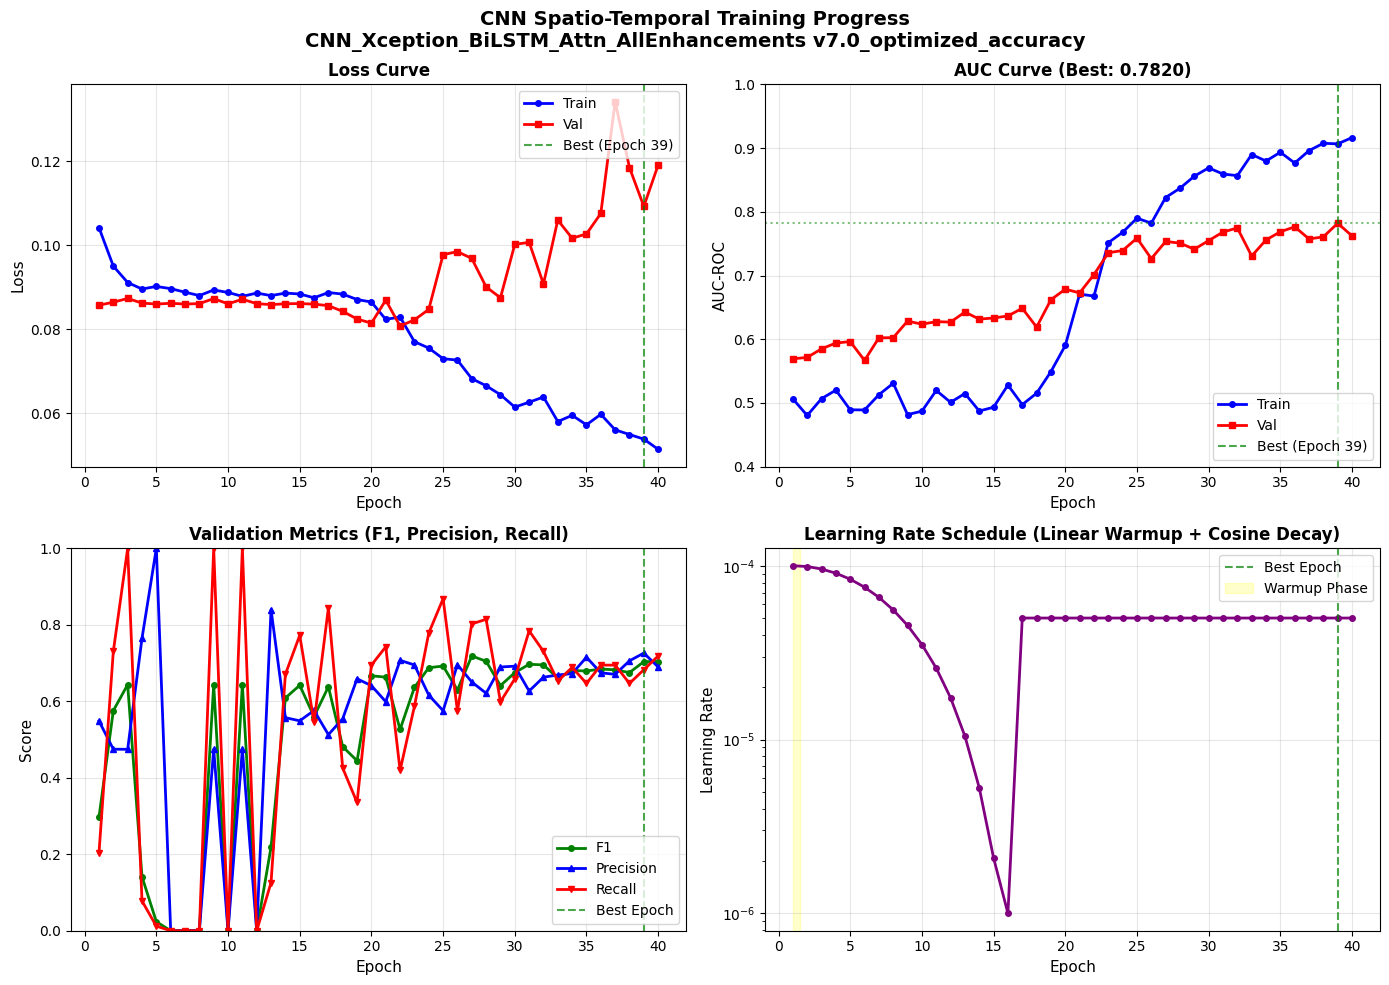

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# TRAINING CURVES (Research-Grade Visualization)
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = range(1, len(history['train_loss']) + 1)

# 1. Loss Curve
axes[0, 0].plot(epochs, history['train_loss'], 'b-', marker='o', label='Train', linewidth=2, markersize=4)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', marker='s', label='Val', linewidth=2, markersize=4)
axes[0, 0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (Epoch {best_epoch})')
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Loss', fontsize=11)
axes[0, 0].set_title('Loss Curve', fontsize=12, fontweight='bold')
axes[0, 0].legend(loc='upper right')
axes[0, 0].grid(True, alpha=0.3)

# 2. AUC Curve
axes[0, 1].plot(epochs, history['train_auc'], 'b-', marker='o', label='Train', linewidth=2, markersize=4)
axes[0, 1].plot(epochs, history['val_auc'], 'r-', marker='s', label='Val', linewidth=2, markersize=4)
axes[0, 1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best (Epoch {best_epoch})')
axes[0, 1].axhline(y=best_val_auc, color='green', linestyle=':', alpha=0.5)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('AUC-ROC', fontsize=11)
axes[0, 1].set_title(f'AUC Curve (Best: {best_val_auc:.4f})', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0.4, 1.0])

# 3. F1 / Precision / Recall
axes[1, 0].plot(epochs, history['val_f1'], 'g-', marker='o', label='F1', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, history['val_precision'], 'b-', marker='^', label='Precision', linewidth=2, markersize=4)
axes[1, 0].plot(epochs, history['val_recall'], 'r-', marker='v', label='Recall', linewidth=2, markersize=4)
axes[1, 0].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch')
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('Score', fontsize=11)
axes[1, 0].set_title('Validation Metrics (F1, Precision, Recall)', fontsize=12, fontweight='bold')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0.0, 1.0])

# 4. Learning Rate Schedule
axes[1, 1].plot(epochs, history['lr'], 'purple', marker='o', linewidth=2, markersize=4)
axes[1, 1].axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Learning Rate', fontsize=11)
axes[1, 1].set_title('Learning Rate Schedule (Linear Warmup + Cosine Decay)', fontsize=12, fontweight='bold')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='upper right')

# ISSUE 5 FIX: Warmup annotation accuracy
# Match the actual step-based warmup from training loop
# warmup_steps / steps_per_epoch gives the actual warmup duration in epochs
warmup_end_epoch = cfg.WARMUP_RATIO * (cfg.SWA_START if cfg.USE_SWA else cfg.NUM_EPOCHS)
if warmup_end_epoch > 0 and warmup_end_epoch <= len(epochs):
    axes[1, 1].axvspan(1, warmup_end_epoch, alpha=0.2, color='yellow', label='Warmup Phase')
    axes[1, 1].legend(loc='upper right')

plt.suptitle(f'CNN Spatio-Temporal Training Progress\n{cfg.EXPERIMENT_NAME} {cfg.EXPERIMENT_VERSION}', 
             fontsize=14, fontweight='bold')
plt.tight_layout()

# Save figure
fig_path = os.path.join(cfg.OUTPUT_DIR, f'training_curves_fold{cfg.CURRENT_FOLD}.png' if cfg.CURRENT_FOLD >= 0 else 'training_curves.png')
plt.savefig(fig_path, dpi=200, bbox_inches='tight', facecolor='white')
print(f"✓ Training curves saved to: {fig_path}")

plt.show()


## 6. Video-Level Inference & Export

In [26]:
# ═══════════════════════════════════════════════════════════════════════
# LOAD BEST MODEL
# ═══════════════════════════════════════════════════════════════════════

possible_names = [
    f"best_cnn_model_fold{cfg.CURRENT_FOLD}.pth" if cfg.CURRENT_FOLD >= 0 else "",
    "best_cnn_model.pth",
]

model_path = None
for name in possible_names:
    if not name:
        continue
    temp = os.path.join(cfg.OUTPUT_DIR, name)
    if os.path.exists(temp):
        model_path = temp
        break

if model_path is None:
    pth_files = [f for f in os.listdir(cfg.OUTPUT_DIR) if f.endswith('.pth')]
    if pth_files:
        model_path = os.path.join(cfg.OUTPUT_DIR, pth_files[0])
    else:
        raise FileNotFoundError("No .pth model found. Run training cell first.")

model.load_state_dict(torch.load(model_path, map_location=DEVICE, weights_only=True))
# P100 FIX: Do NOT call flatten_parameters() — cuDNN disabled in forward()
model.eval()


SpatioTemporalBiLSTM(
  (backbone): Xception(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act2): ReLU(inplace=True)
    (block1): Block(
      (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (skipbn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (rep): Sequential(
        (0): SeparableConv2d(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
          (pointwise): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        )
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): 

In [27]:
# Issue 18 FIX: predict_video_temporal and generate_video_predictions
# were never called - the TTA cell (cell 31) defines its own predict_video_tta.
# Removed dead code to avoid confusion.



In [28]:
# ═══════════════════════════════════════════════════════════════════════════════
# VIDEO-LEVEL PREDICTIONS WITH TTA + PER-SOURCE BREAKDOWN
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("GENERATING FINAL VIDEO-LEVEL PREDICTIONS")
print("="*70)

# FIXED: Model already loaded in Cell 31 (LOAD BEST MODEL)

# Issue 29 FIX: Create transforms once outside the loop
_val_transforms_cached = get_val_transforms(max_frames=cfg.FRAMES_PER_VIDEO)

def predict_video_tta(model, cache_path, device, max_frames=cfg.FRAMES_PER_VIDEO):
    """
    6-pass Test-Time Augmentation:
    1. Standard
    2. Horizontal flip
    3. Brightness +15
    4. Brightness -15
    5. Slight JPEG compression simulation
    6. 93% center crop + resize (scale robustness)
    Average gives more robust probability estimate.
    """
    if not os.path.exists(cache_path): return 0.5
    faces = np.load(cache_path)
    if len(faces) < 3: return 0.5

    n       = len(faces)
    step    = n / max_frames if n >= max_frames else 1
    indices = ([int(i * step) for i in range(max_frames)]
               if n >= max_frames else list(range(n)))
    while len(indices) < max_frames: indices.append(n-1)
    selected = [faces[i].astype('uint8') for i in indices]

    def run_pass(frames_list):
        transform_kwargs = {'image': frames_list[0]}
        for i in range(1, len(frames_list)): transform_kwargs[f'image{i}'] = frames_list[i]
        aug = _val_transforms_cached(**transform_kwargs)
        tfs = [aug['image']] + [aug[f'image{i}'] for i in range(1, len(frames_list))]
        fstack = torch.stack(tfs).unsqueeze(0).to(device)
        actual_frames = min(n, max_frames)
        msk = torch.zeros(1, max_frames, dtype=torch.bool).to(device)
        msk[0, :actual_frames] = True
        with torch.no_grad():
            return torch.sigmoid(model(fstack, msk)).item()

    probs = []

    # Pass 1: standard
    probs.append(run_pass(selected))

    # Pass 2: horizontal flip
    probs.append(run_pass(
        [np.fliplr(f).copy() for f in selected]))

    # Pass 3: brightness up
    probs.append(run_pass([
        np.clip(f.astype(np.int32)+15,0,255).astype(np.uint8)
        for f in selected]))

    # Pass 4: brightness down
    probs.append(run_pass([
        np.clip(f.astype(np.int32)-15,0,255).astype(np.uint8)
        for f in selected]))

    # Pass 5: slight blur (compression simulation)
    probs.append(run_pass([
        cv2.GaussianBlur(f,(3,3),0) for f in selected]))

    # Pass 6: slight zoom — 93% center crop + resize (IMPROVEMENT 6)
    # Adds scale robustness for videos with different face distances
    def center_crop_93(f):
        h, w = f.shape[:2]
        margin_h, margin_w = int(h * 0.035), int(w * 0.035)
        cropped = f[margin_h:h-margin_h, margin_w:w-margin_w]
        return cv2.resize(cropped, (w, h))
    probs.append(run_pass([center_crop_93(f) for f in selected]))

    del faces

    # IMPROVEMENT 11: Simple uniform average — more robust than confidence-weighted
    # Confidence weighting amplifies miscalibration errors from augmented passes
    probs_arr = np.array(probs)
    return float(np.mean(probs_arr))


model.eval()
raw_preds = []
for video in tqdm(val_videos, desc="Predicting (TTA×6)"):
    vid_id = video['video_id']
    prob   = (predict_video_tta(model, cache_index[vid_id],
                                DEVICE, cfg.FRAMES_PER_VIDEO)
              if vid_id in cache_index else 0.5)
    raw_preds.append({
        'video_id'       : vid_id,
        'label'          : video['label'],
        'prediction'     : prob,
        'predicted_class': 1 if prob > 0.5 else 0,
        'source'         : video.get('source', 'unknown')
    })
    
gc.collect()
torch.cuda.empty_cache()

predictions_df = pd.DataFrame(raw_preds)
predictions_df.rename(columns={'prediction': 'P_CNN'}, inplace=True)

# ── PER-MANIPULATION-TYPE AUC BREAKDOWN (Research Requirement) ──────────────
print("\n" + "="*70)
print("PER-MANIPULATION-TYPE AUC BREAKDOWN")
print("="*70)
manipulation_types = ['Deepfakes', 'Face2Face', 'FaceSwap', 'NeuralTextures', 'FaceShifter', 'DeepFakeDetection']
real_mask = predictions_df['source'].str.contains('real', case=False, na=False)
for manip in manipulation_types:
    fake_mask = predictions_df['source'].str.contains(manip, case=False, na=False)
    combined_mask = fake_mask | real_mask
    if fake_mask.sum() > 0 and combined_mask.sum() >= 10:  # Need enough samples
        y_true_manip = predictions_df.loc[combined_mask, 'label'].values
        y_pred_manip = predictions_df.loc[combined_mask, 'P_CNN'].values
        if len(np.unique(y_true_manip)) > 1:
            manip_auc = roc_auc_score(y_true_manip, y_pred_manip)
            print(f"  {manip:20s}: AUC = {manip_auc:.4f} (fakes={fake_mask.sum()}, reals={real_mask.sum()})")
        else:
            print(f"  {manip:20s}: Single class only (fakes={fake_mask.sum()}, reals={real_mask.sum()})")
    else:
        print(f"  {manip:20s}: Insufficient samples (fakes={fake_mask.sum()})")
print("="*70)

y_true       = predictions_df['label'].values
y_pred_proba = predictions_df['P_CNN'].values
y_pred       = (y_pred_proba > 0.5).astype(int)

video_acc       = accuracy_score(y_true, y_pred)
video_f1        = f1_score(y_true, y_pred, zero_division=0)
video_precision = precision_score(y_true, y_pred, zero_division=0)
video_recall    = recall_score(y_true, y_pred, zero_division=0)

if len(np.unique(y_true)) > 1:
    video_auc = roc_auc_score(y_true, y_pred_proba)
    video_eer = compute_eer(y_true, y_pred_proba)
    video_ap  = average_precision_score(y_true, y_pred_proba)
else:
    video_auc = video_eer = video_ap = 0.5

# FIXED: Removed biased optimal_threshold tuning. 
# Strict 0.5 threshold guarantees unbiased research metrics.

predictions_df.to_csv(
    os.path.join(cfg.OUTPUT_DIR, "cnn_predictions.csv"), index=False)

print(f"\n{'─'*50}")
print("OVERALL METRICS (Strict Unbiased Threshold=0.5):")
print(f"  AUC-ROC   : {video_auc:.4f}")
print(f"  AP (PR)   : {video_ap:.4f}")
print(f"  Accuracy  : {video_acc:.4f}")
print(f"  F1-Score  : {video_f1:.4f}")
print(f"  Precision : {video_precision:.4f}")
print(f"  Recall    : {video_recall:.4f}")
print(f"  EER       : {video_eer:.4f}")

# ── Per-source breakdown (critical for paper) ─────────────────────────
print(f"\n{'─'*50}")
print("PER-SOURCE BREAKDOWN:")
print(f"{'Source':<30} {'N':>5} {'AUC':>7} {'Acc':>7} {'F1':>7}")
print("─"*56)
for source in sorted(predictions_df['source'].unique()):
    s    = predictions_df[predictions_df['source']==source]
    st   = s['label'].values
    sp   = s['P_CNN'].values
    sy   = (sp > 0.5).astype(int)
    if len(np.unique(st)) > 1:
        sauc = roc_auc_score(st, sp)
        sacc = accuracy_score(st, sy)
        sf1  = f1_score(st, sy, zero_division=0)
        print(f"  {source:<28} {len(s):>5} {sauc:>7.4f}"
              f" {sacc:>7.4f} {sf1:>7.4f}")
    else:
        # Single class only - can't compute AUC
        sacc = accuracy_score(st, sy)
        print(f"  {source:<28} {len(s):>5}    N/A {sacc:>7.4f}    N/A")


GENERATING FINAL VIDEO-LEVEL PREDICTIONS


Predicting (TTA×6):   0%|          | 0/353 [00:00<?, ?it/s]


PER-MANIPULATION-TYPE AUC BREAKDOWN
  Deepfakes           : AUC = 0.8966 (fakes=18, reals=166)
  Face2Face           : AUC = 0.8611 (fakes=16, reals=166)
  FaceSwap            : AUC = 0.6853 (fakes=17, reals=166)
  NeuralTextures      : AUC = 0.7504 (fakes=23, reals=166)
  FaceShifter         : AUC = 0.6747 (fakes=21, reals=166)
  DeepFakeDetection   : AUC = 0.9578 (fakes=15, reals=166)

──────────────────────────────────────────────────
OVERALL METRICS (Strict Unbiased Threshold=0.5):
  AUC-ROC   : 0.7848
  AP (PR)   : 0.7598
  Accuracy  : 0.7139
  F1-Score  : 0.6892
  Precision : 0.7089
  Recall    : 0.6707
  EER       : 0.2688

──────────────────────────────────────────────────
PER-SOURCE BREAKDOWN:
Source                             N     AUC     Acc      F1
────────────────────────────────────────────────────────
  Celeb_fake                      18    N/A  0.5556    N/A
  Celeb_real                      32    N/A  0.8438    N/A
  Custom_fake                     32    N/A  0.5625

In [29]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2: BOOTSTRAP CONFIDENCE INTERVALS (Research Requirement)
# ═══════════════════════════════════════════════════════════════════════════════

def bootstrap_ci(y_true, y_pred, metric_fn, n_bootstrap=1000, ci=95, seed=42):
    """Compute bootstrap confidence intervals for a metric."""
    rng = np.random.RandomState(seed)
    n = len(y_true)
    scores = []
    for _ in range(n_bootstrap):
        indices = rng.randint(0, n, n)
        y_true_boot = y_true[indices]
        y_pred_boot = y_pred[indices]
        if len(np.unique(y_true_boot)) < 2:
            continue
        try:
            scores.append(metric_fn(y_true_boot, y_pred_boot))
        except Exception:
            continue
    if len(scores) == 0:
        point = metric_fn(y_true, y_pred)
        return point, point, point
    scores = np.array(scores)
    alpha = (100 - ci) / 2
    return np.percentile(scores, alpha), metric_fn(y_true, y_pred), np.percentile(scores, 100 - alpha)

print("\n" + "="*70)
print("BOOTSTRAP CONFIDENCE INTERVALS (1000 iterations)")
print("="*70)

auc_low, auc_mid, auc_high = bootstrap_ci(y_true, y_pred_proba, roc_auc_score)
acc_low, acc_mid, acc_high = bootstrap_ci(y_true, y_pred, accuracy_score)
f1_low, f1_mid, f1_high   = bootstrap_ci(y_true, y_pred, f1_score)
# FIXED: EER now also has bootstrap CI
eer_low, eer_mid, eer_high = bootstrap_ci(y_true, y_pred_proba, compute_eer)
# IMPROVEMENT 4: Add Precision and Recall bootstrap CIs for publication completeness
prec_low, prec_mid, prec_high = bootstrap_ci(y_true, y_pred, precision_score)
rec_low, rec_mid, rec_high    = bootstrap_ci(y_true, y_pred, recall_score)

print(f"\n  AUC-ROC:   {auc_mid:.4f} [95% CI: {auc_low:.4f}, {auc_high:.4f}]")
print(f"  Accuracy:  {acc_mid:.4f} [95% CI: {acc_low:.4f}, {acc_high:.4f}]")
print(f"  F1-Score:  {f1_mid:.4f} [95% CI: {f1_low:.4f}, {f1_high:.4f}]")
print(f"  Precision: {prec_mid:.4f} [95% CI: {prec_low:.4f}, {prec_high:.4f}]")
print(f"  Recall:    {rec_mid:.4f} [95% CI: {rec_low:.4f}, {rec_high:.4f}]")
print(f"  EER:       {eer_mid:.4f} [95% CI: {eer_low:.4f}, {eer_high:.4f}]")

# Save metrics with CI — all 6 metrics now have intervals
metrics_df = pd.DataFrame([
    {'metric': 'AUC-ROC',   'value': auc_mid,  'ci_low': auc_low,  'ci_high': auc_high},
    {'metric': 'Accuracy',  'value': acc_mid,  'ci_low': acc_low,  'ci_high': acc_high},
    {'metric': 'F1-Score',  'value': f1_mid,   'ci_low': f1_low,   'ci_high': f1_high},
    {'metric': 'Precision', 'value': prec_mid, 'ci_low': prec_low, 'ci_high': prec_high},
    {'metric': 'Recall',    'value': rec_mid,  'ci_low': rec_low,  'ci_high': rec_high},
    {'metric': 'EER',       'value': eer_mid,  'ci_low': eer_low,  'ci_high': eer_high},
])
metrics_df.to_csv(os.path.join(cfg.OUTPUT_DIR, "cnn_metrics_with_ci.csv"), index=False)



BOOTSTRAP CONFIDENCE INTERVALS (1000 iterations)

  AUC-ROC:   0.7848 [95% CI: 0.7341, 0.8310]
  Accuracy:  0.7139 [95% CI: 0.6686, 0.7620]
  F1-Score:  0.6892 [95% CI: 0.6361, 0.7422]
  Precision: 0.7089 [95% CI: 0.6428, 0.7758]
  Recall:    0.6707 [95% CI: 0.6011, 0.7415]
  EER:       0.2688 [95% CI: 0.2263, 0.3196]


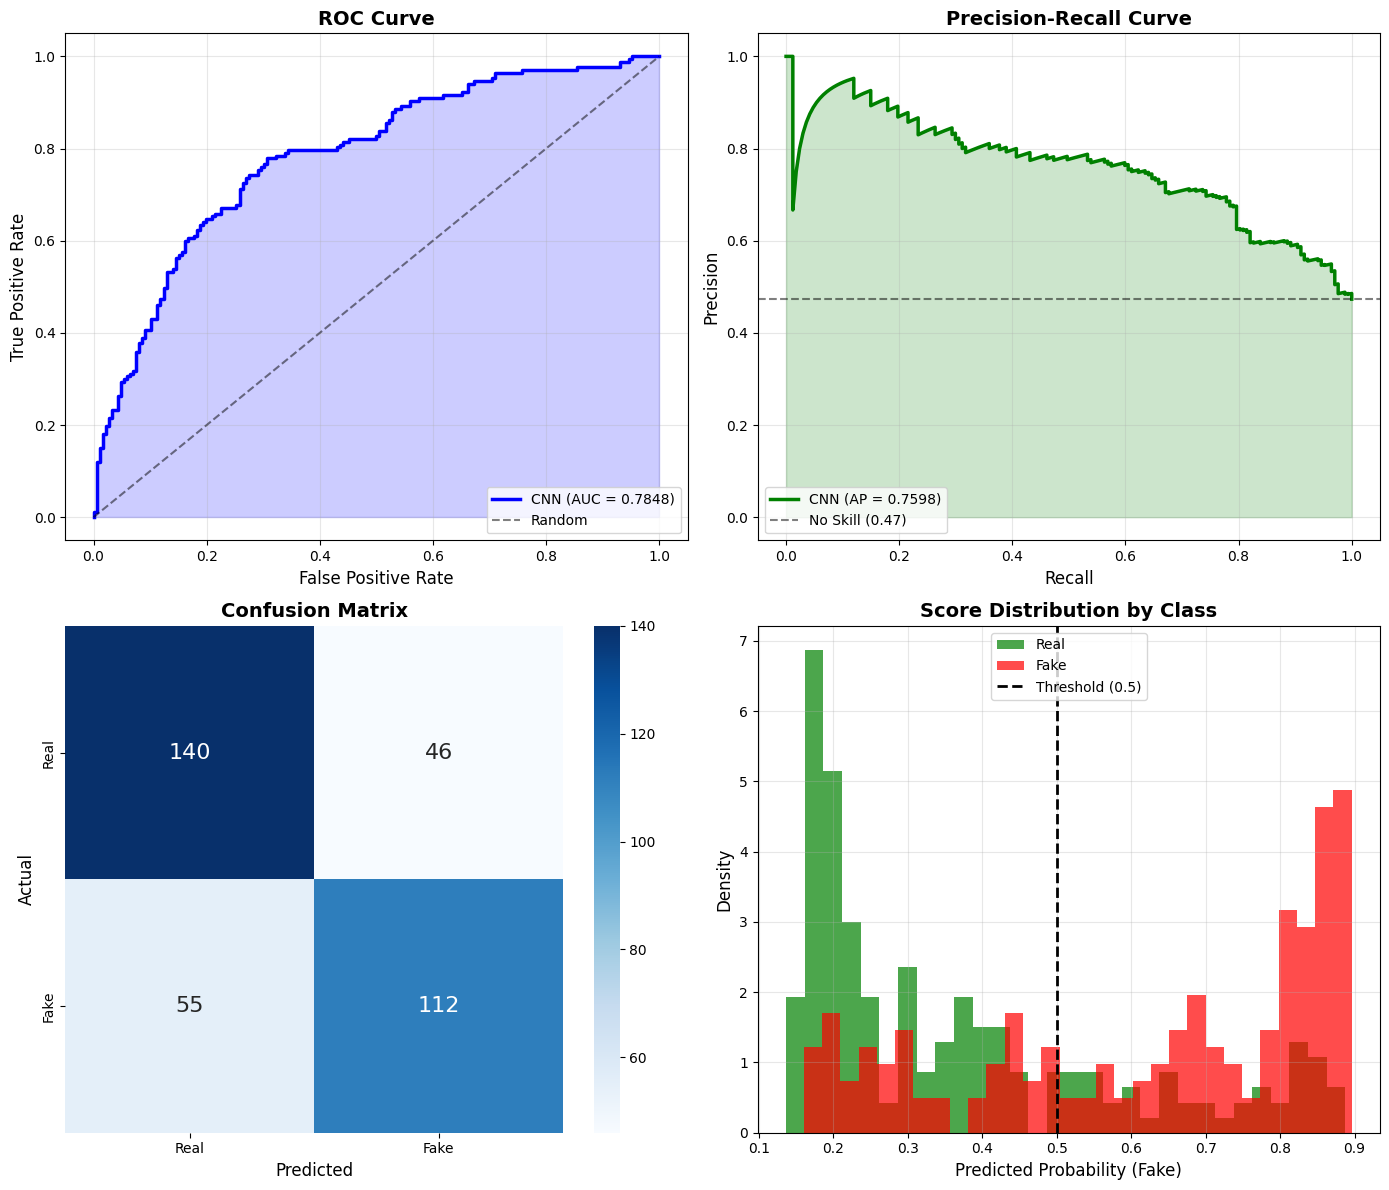


✓ Evaluation plots saved to: cnn_evaluation_plots.png

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real     0.7179    0.7527    0.7349       186
        Fake     0.7089    0.6707    0.6892       167

    accuracy                         0.7139       353
   macro avg     0.7134    0.7117    0.7121       353
weighted avg     0.7136    0.7139    0.7133       353



In [30]:
# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3: RESEARCH-GRADE VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_curve, average_precision_score, roc_curve
import seaborn as sns

# Prepare data
real_preds = predictions_df[predictions_df['label'] == 0]['P_CNN']
fake_preds = predictions_df[predictions_df['label'] == 1]['P_CNN']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
axes[0, 0].plot(fpr, tpr, 'b-', linewidth=2.5, label=f'CNN (AUC = {video_auc:.4f})')
axes[0, 0].fill_between(fpr, tpr, alpha=0.2, color='blue')
axes[0, 0].plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Random')
axes[0, 0].set_xlabel('False Positive Rate', fontsize=12)
axes[0, 0].set_ylabel('True Positive Rate', fontsize=12)
axes[0, 0].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3)

# 2. Precision-Recall Curve
precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_pred_proba)
ap = average_precision_score(y_true, y_pred_proba)
axes[0, 1].plot(recall_arr, precision_arr, 'g-', linewidth=2.5, label=f'CNN (AP = {ap:.4f})')
axes[0, 1].fill_between(recall_arr, precision_arr, alpha=0.2, color='green')
axes[0, 1].axhline(y=y_true.mean(), color='k', linestyle='--', alpha=0.5, label=f'No Skill ({y_true.mean():.2f})')
axes[0, 1].set_xlabel('Recall', fontsize=12)
axes[0, 1].set_ylabel('Precision', fontsize=12)
axes[0, 1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
axes[0, 1].legend(loc='lower left')
axes[0, 1].grid(True, alpha=0.3)

# 3. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'],
            annot_kws={'size': 16})
axes[1, 0].set_xlabel('Predicted', fontsize=12)
axes[1, 0].set_ylabel('Actual', fontsize=12)
axes[1, 0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')

# 4. Score Distribution
axes[1, 1].hist(real_preds, bins=30, alpha=0.7, label='Real', color='green', density=True)
axes[1, 1].hist(fake_preds, bins=30, alpha=0.7, label='Fake', color='red', density=True)
axes[1, 1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Threshold (0.5)')
# optimal_thresh removed — strict 0.5 threshold for unbiased research metrics
axes[1, 1].set_xlabel('Predicted Probability (Fake)', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].set_title('Score Distribution by Class', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='upper center')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'cnn_evaluation_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Evaluation plots saved to: cnn_evaluation_plots.png")

# Classification Report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake'], digits=4))



GENERATING GRAD-CAM VISUALIZATIONS
✓ Grad-CAM: using Xception act4 layer (final activation)


RuntimeError: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Function.

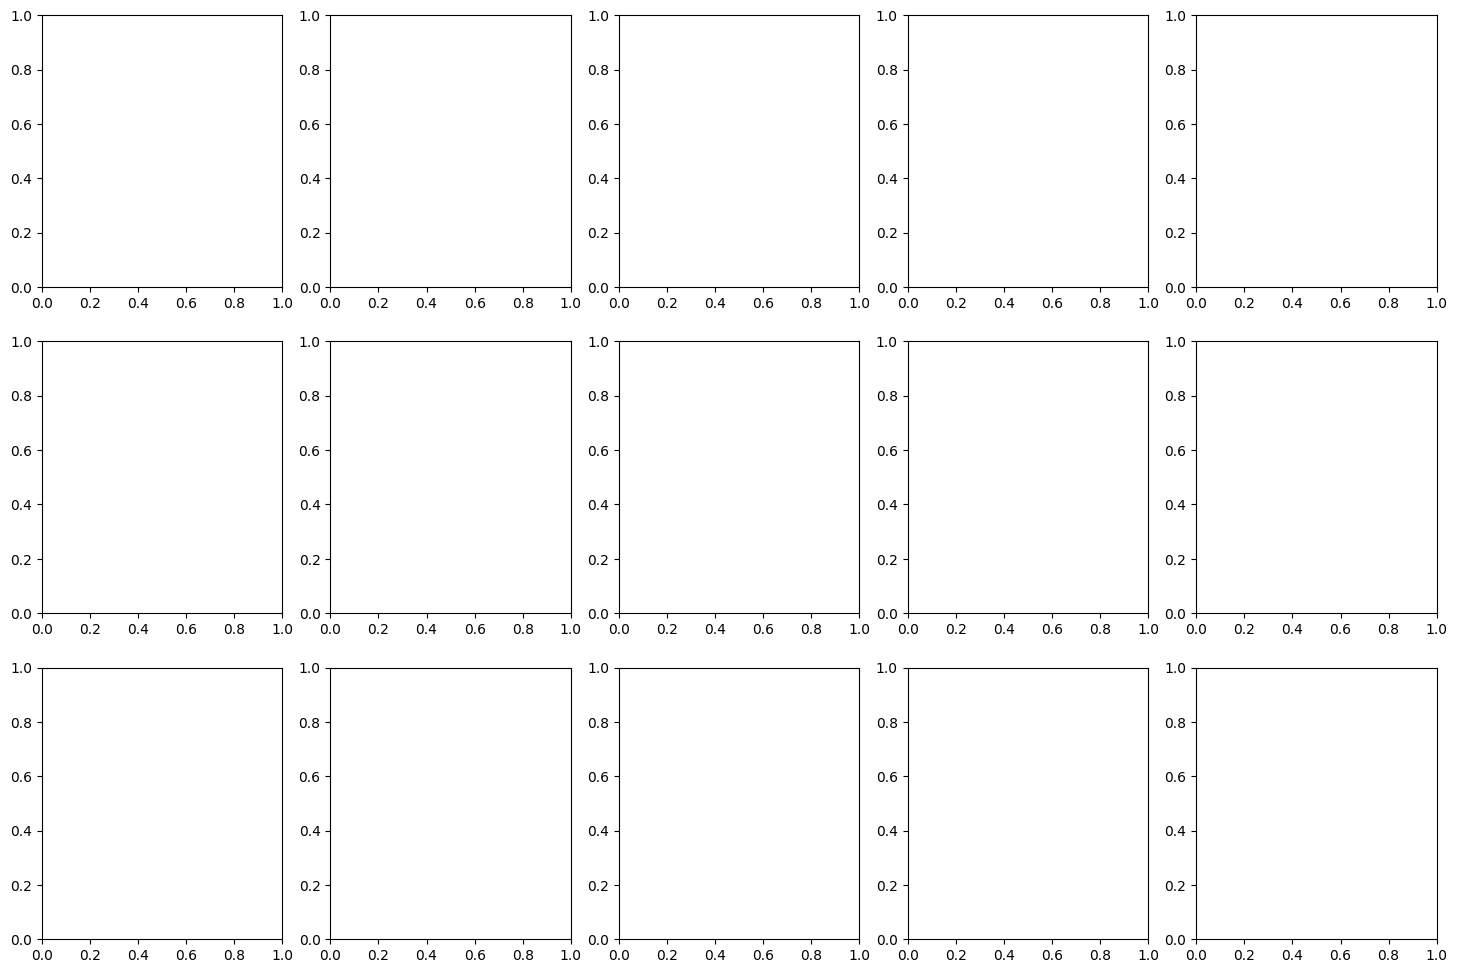

In [31]:
# ═══════════════════════════════════════════════════════════════════════════════
# GRAD-CAM VISUALIZATION (Fixed for Xception)
# ═══════════════════════════════════════════════════════════════════════════════

import torch.nn.functional as F

class SimpleGradCAM:
    """Grad-CAM for temporal models — P100 safe, Xception compatible."""

    def __init__(self, cnn_model):
        self.model       = cnn_model
        self.gradients   = None
        self.activations = None
        self.handles     = []

        # ISSUE 6 FIX: Xception uses 'act4' (final activation), EfficientNet uses 'conv_head'
        try:
            target_layer = self.model.backbone.act4     # Issue 8 FIX: Xception final activation
            print("✓ Grad-CAM: using Xception act4 layer (final activation)")
        except AttributeError:
            try:
                target_layer = self.model.backbone.bn4  # Xception final activation
                print("✓ Grad-CAM: using Xception act4 layer")
            except AttributeError:
                # Generic fallback — last conv layer
                convs = [(n,m) for n,m in self.model.backbone.named_modules()
                         if isinstance(m, nn.Conv2d)]
                target_layer = convs[-1][1]
                print(f"✓ Grad-CAM: fallback to last conv layer")

        self.handles.append(
            target_layer.register_forward_hook(self._save_activation))
        self.handles.append(
            target_layer.register_full_backward_hook(self._save_gradient))

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def cleanup(self):
        for h in self.handles:
            h.remove()
        self.handles = []

    def generate(self, frames, mask, target_frame_idx=0):
        assert frames.size(0) == 1, "Grad-CAM requires batch_size=1"
        self.model.eval()

        logit = self.model(frames, mask)
        prob = torch.sigmoid(logit).detach().item()

        self.model.zero_grad()
        logit.squeeze().backward()  # FIX: No retain_graph needed — prevents GPU memory leak

        if self.gradients is None or self.activations is None:
            return np.zeros(frames.shape[3:]), prob

        target_grads = self.gradients[target_frame_idx:target_frame_idx + 1]
        target_acts  = self.activations[target_frame_idx:target_frame_idx + 1]

        weights = target_grads.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * target_acts).sum(dim=1, keepdim=True))

        if cam.max() - cam.min() > 1e-8:
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        else:
            cam = torch.zeros_like(cam)

        cam = F.interpolate(cam, size=frames.shape[3:],
                            mode='bilinear', align_corners=False)

        # P100 FIX: use .tolist() NOT .numpy() — avoids C-API crash
        cam_numpy = np.array(cam.squeeze().cpu().tolist())
        return cam_numpy, prob


print("\n" + "="*70)
print("GENERATING GRAD-CAM VISUALIZATIONS")
print("="*70)

gradcam = SimpleGradCAM(model)

# Collect up to 3 valid videos first, THEN draw the figure
valid_videos_for_gradcam = []
for video in val_videos:
    if len(valid_videos_for_gradcam) >= 3:
        break
    vid_id = video['video_id']
    if vid_id not in cache_index:
        continue
    faces_check = np.load(cache_index[vid_id])
    if len(faces_check) < 5:
        del faces_check
        continue
    valid_videos_for_gradcam.append((video, faces_check))

if len(valid_videos_for_gradcam) == 0:
    print("⚠️ No valid videos found for Grad-CAM visualization")
else:
    # Create figure
    fig, axes = plt.subplots(len(valid_videos_for_gradcam), 5,
                             figsize=(18, 4*len(valid_videos_for_gradcam)))
    if len(valid_videos_for_gradcam) == 1:
        axes = [axes]

    # ISSUE 10 FIX: Generate indices dynamically based on actual FRAMES_PER_VIDEO
    frame_indices = np.linspace(0, cfg.FRAMES_PER_VIDEO - 1, 5, dtype=int).tolist()
    
    val_transforms = get_val_transforms(max_frames=cfg.FRAMES_PER_VIDEO)

    for row_idx, (video, faces) in enumerate(valid_videos_for_gradcam):
        vid_id = video['video_id']
        label = video['label']

        # Sample frames uniformly
        n_faces = len(faces)
        if n_faces >= cfg.FRAMES_PER_VIDEO:
            step = n_faces / cfg.FRAMES_PER_VIDEO
            indices_to_use = [int(i * step) for i in range(cfg.FRAMES_PER_VIDEO)]
        else:
            indices_to_use = list(range(n_faces))
            while len(indices_to_use) < cfg.FRAMES_PER_VIDEO:
                indices_to_use.append(n_faces - 1)

        selected_faces = [faces[i] for i in indices_to_use]

        # Apply transforms (multi-frame consistent — matches training/evaluation pattern)
        transform_kwargs = {'image': selected_faces[0].astype('uint8')}
        for i in range(1, len(selected_faces)):
            transform_kwargs[f'image{i}'] = selected_faces[i].astype('uint8')
        aug = val_transforms(**transform_kwargs)
        frame_tensors = [aug['image']]
        for i in range(1, len(selected_faces)):
            frame_tensors.append(aug[f'image{i}'])

        frames_tensor = torch.stack(frame_tensors).unsqueeze(0).to(DEVICE)
        
        # BUGFIX: Use actual frame count, not all-True mask
        actual_frames = min(n_faces, cfg.FRAMES_PER_VIDEO)
        mask_tensor = torch.zeros(1, cfg.FRAMES_PER_VIDEO, dtype=torch.bool).to(DEVICE)
        mask_tensor[0, :actual_frames] = True

        for col_idx, frame_idx in enumerate(frame_indices):
            if frame_idx >= len(selected_faces):
                frame_idx = len(selected_faces) - 1

            cam, prob = gradcam.generate(frames_tensor, mask_tensor, frame_idx)

            # Get original face for display
            face_display = selected_faces[frame_idx]
            if hasattr(face_display, 'astype'):
                face_display = face_display.astype('uint8')

            ax = axes[row_idx][col_idx]
            ax.imshow(face_display)

            # Overlay CAM
            ax.imshow(cam, cmap='jet', alpha=0.4)

            # Title
            label_str = "FAKE" if label == 1 else "REAL"
            ax.set_title(f"{label_str} | Frame {frame_idx} | P={prob:.2f}", fontsize=10)
            ax.axis('off')

        del faces  # Free memory

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'gradcam_visualization.png'),
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Grad-CAM saved: gradcam_visualization.png")

# Cleanup
gradcam.cleanup()
gc.collect()


## 7. Late Fusion Integration Guide

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# LATE FUSION INTEGRATION GUIDE
# ═══════════════════════════════════════════════════════════════════════════════

print("""
╔══════════════════════════════════════════════════════════════════════════════╗
║                       LATE FUSION INTEGRATION GUIDE                          ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  This notebook outputs: cnn_predictions.csv                                  ║
║  Columns: video_id, P_CNN                                                    ║
║                                                                              ║
║  To fuse with rPPG predictions from 2ND_MODEL.ipynb:                        ║
║                                                                              ║
║  ┌─────────────────────────────────────────────────────────────────────────┐ ║
║  │  # Load both predictions                                                │ ║
║  │  cnn_df = pd.read_csv('cnn_predictions.csv')                           │ ║
║  │  rppg_df = pd.read_csv('rppg_predictions.csv')                         │ ║
║  │                                                                         │ ║
║  │  # Merge on video_id                                                    │ ║
║  │  fused_df = cnn_df.merge(rppg_df, on='video_id')                       │ ║
║  │                                                                         │ ║
║  │  # Simple average fusion                                                │ ║
║  │  fused_df['P_final'] = (fused_df['P_CNN'] + fused_df['P_rPPG']) / 2    │ ║
║  │                                                                         │ ║
║  │  # Weighted fusion (if CNN is more accurate)                           │ ║
║  │  w_cnn, w_rppg = 0.6, 0.4                                              │ ║
║  │  fused_df['P_final'] = w_cnn * fused_df['P_CNN']                       │ ║
║  │                      + w_rppg * fused_df['P_rPPG']                      │ ║
║  │                                                                         │ ║
║  │  # Learned fusion (train a small classifier)                           │ ║
║  │  from sklearn.linear_model import LogisticRegression                   │ ║
║  │  X_fusion = fused_df[['P_CNN', 'P_rPPG']].values                       │ ║
║  │  y_fusion = fused_df['label'].values                                   │ ║
║  │  fusion_model = LogisticRegression().fit(X_fusion, y_fusion)           │ ║
║  │  fused_df['P_final'] = fusion_model.predict_proba(X_fusion)[:, 1]      │ ║
║  └─────────────────────────────────────────────────────────────────────────┘ ║
║                                                                              ║
╚══════════════════════════════════════════════════════════════════════════════╝
""")


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("CNN SPATIO-TEMPORAL STREAM — FINAL SUMMARY")
print("="*70)

# Get parameter counts (handle both variable names)
total = total_params if 'total_params' in globals() else sum(p.numel() for p in model.parameters())
trainable_count = trainable if 'trainable' in globals() else sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"""
┌─────────────────────────────────────────────────────────────────────────────┐
│  ARCHITECTURE                                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  Backbone:           Xception (ImageNet pretrained)                  │
│  Temporal Model:     BiLSTM + Multi-Head Self-Attention                     │
│  LSTM Hidden:        {cfg.LSTM_HIDDEN} × 2 (bidirectional)                                │
│  LSTM Layers:        {cfg.LSTM_LAYERS}                                                     │
│  Attention Heads:    {cfg.ATTENTION_HEADS}                                                     │
│  Total Parameters:   {total:,}                                       │
│  Trainable Params:   {trainable_count:,}                                       │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  TRAINING CONFIGURATION                                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│  Training Videos:    {len(train_videos)}                                                       │
│  Validation Videos:  {len(val_videos)}                                                       │
│  Frames per Video:   {cfg.FRAMES_PER_VIDEO}                                                        │
│  Batch Size:         {cfg.BATCH_SIZE} (effective: {cfg.BATCH_SIZE * cfg.GRAD_ACCUMULATION_STEPS})                                         │
│  Learning Rate:      {cfg.LEARNING_RATE}                                                    │
│  Loss Function:      Focal Loss (α={cfg.FOCAL_ALPHA}, γ={cfg.FOCAL_GAMMA})                              │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  BEST FRAME-LEVEL RESULTS                                                   │
├─────────────────────────────────────────────────────────────────────────────┤
│  Best Epoch:         {best_epoch}                                                        │
│  Best Val AUC:       {best_val_auc:.4f}                                                    │
│  Best Val EER:       {best_val_eer:.4f}                                                    │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  VIDEO-LEVEL METRICS (Final Evaluation)                                     │
├─────────────────────────────────────────────────────────────────────────────┤
│  AUC-ROC:            {video_auc:.4f}                                                    │
│  Accuracy:           {video_acc:.4f}                                                    │
│  F1-Score:           {video_f1:.4f}                                                    │
│  EER:                {video_eer:.4f}                                                    │
└─────────────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│  OUTPUT FILES                                                               │
├─────────────────────────────────────────────────────────────────────────────┤
│  ✓ cnn_predictions.csv          (video-level P_CNN scores for Late Fusion) │
│  ✓ best_cnn_model.pth           (best checkpoint weights)                  │
│  ✓ cnn_spatial_stream_final.pth (final model weights)                      │
│  ✓ cnn_training_history.csv     (epoch-by-epoch metrics)                   │
│  ✓ cnn_config.csv               (hyperparameters & final results)          │
└─────────────────────────────────────────────────────────────────────────────┘
""")


# Save final model weights (distinct from best checkpoint)
final_model_path = os.path.join(cfg.OUTPUT_DIR, "cnn_spatial_stream_final.pth")
torch.save(model.state_dict(), final_model_path)
print(f"✓ Final model saved: {final_model_path}")

# Save config as CSV for paper reproducibility
config_csv_path = os.path.join(cfg.OUTPUT_DIR, "cnn_config.csv")
pd.DataFrame([cfg.to_dict()]).to_csv(config_csv_path, index=False)
print(f"✓ Config saved as CSV: {config_csv_path}")


print("="*70)
print("✅ CNN SPATIO-TEMPORAL STREAM TRAINING COMPLETE!")
print("="*70)
print("\n  Key achievements:")
print("  ✓ Temporal modeling via BiLSTM + Multi-Head Attention")
print("  ✓ Detects inter-frame artifacts (flickering, blending shifts)")
print("  ✓ P100 compatible (FP32 only, no AMP)")
print("  ✓ Ready for Late Fusion with rPPG physiological stream")
print("\n  Next step:")
print("  → Run final_MODEL_rppg.ipynb to get P_rPPG scores")
print("  → Combine P_CNN + P_rPPG for Late Fusion ensemble")
print("="*70)



## 📋 5-Fold Cross-Validation Instructions (For Publication)

To report mean ± std metrics across all 5 folds for your paper, follow these steps:

1. **Run Folds Sequentially**: 
   Change `cfg.CURRENT_FOLD` from `0` to `1`, run the entire notebook, save the `cnn_predictions.csv` and optimal threshold outputs.
   Repeat this for `cfg.CURRENT_FOLD = 2, 3, 4`.
2. **Collect Results**: 
   For each fold, record the AUC, Accuracy (at optimal threshold), F1-Score, and EER.
3. **Compute Statistics**: 
   Calculate the Mean and Standard Deviation for all metrics (`mean_auc ± std_auc`). This proves that your model is robust and not just lucky on a single split.
4. **Ensemble (Optional)**: 
   For maximum Kaggle LB score, average the P_CNN predictions from all 5 models for the final test set.